# Deep Learning — Module 2: Training & Optimization · Part 1
## Loss Functions & Backpropagation

> **Who is this for?**
> From first-time learners to senior MLEs preparing for system design interviews.
> Every concept is explained in three layers:
> 1. **Intuition** — a real-world analogy before any math
> 2. **Math** — the precise equations
> 3. **Code** — working Python that demonstrates the concept numerically or visually

---

## Table of Contents

| Section | Topic |
|---------|-------|
| **1** | The Big Picture — The Learning Loop |
| **2.1** | MSE Loss |
| **2.2** | MAE Loss & Robustness to Outliers |
| **2.3** | Huber Loss — Best of Both Worlds |
| **2.4** | Binary Cross-Entropy (BCE) |
| **2.5** | Categorical Cross-Entropy & NLL Loss |
| **2.6** | Bonus: Focal Loss |
| **2.7** | Loss Landscape Visualization |
| **3.1** | Backpropagation — Forward vs Backward Pass |
| **3.2** | Chain Rule — The Core Mechanism |
| **3.3** | Manual Backprop: Worked Example (2-Layer Net) |
| **3.4** | Computational Graphs & Autodiff |
| **3.5** | Vanishing & Exploding Gradients |
| **3.6** | Gradient Clipping |
| **4** | NumPy: Manual Forward + Backward Pass |
| **5** | PyTorch: Autograd Demo |
| **6** | Master Interview Q&A Cheatsheet |

> **Bonus: Log-Cosh Loss**
> An alternative to Huber is **Log-Cosh**. It computes `log(cosh(prediction - true))`. It behaves exactly like MSE for small errors and like MAE for large errors, but unlike Huber, it is infinitely differentiable everywhere and **doesn't require tuning a hyperparameter** (like delta in Huber).


In [1]:
# ── Cell 1: All imports — run this first ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import softmax as scipy_softmax

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "axes.prop_cycle": plt.cycler(color=[
        "#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"
    ])
})
print("All imports ready ✓")


All imports ready ✓


## 1. The Big Picture — The Learning Loop

### Intuition
Imagine you are learning to throw darts. Here is what happens every throw:
1. You throw the dart — it lands *somewhere* (**Forward Pass**)
2. You measure how far from the bullseye (**Loss Function**)
3. You figure out which way your arm moved wrong (**Backpropagation**)
4. You adjust your throwing technique (**Optimizer Step**)

You repeat this loop thousands of times and gradually get better. Neural network training is **exactly** this loop.

---

### The Four Steps

```
Input x ──► [ Network f(x; W) ] ──► Prediction ŷ
                                         │
                                    Loss L(ŷ, y)    ◄── True label y
                                         │
                              ∂L/∂W  ◄──┘  (Backprop)
                                         │
                              W ← W - lr·∂L/∂W      (Optimizer)
```

| Step | Name | Question it answers |
|------|------|----------------------|
| 1 | **Forward Pass** | "What does the network predict?" |
| 2 | **Loss Computation** | "How wrong is the prediction?" |
| 3 | **Backpropagation** | "Which weights caused the error, and by how much?" |
| 4 | **Optimizer Step** | "How do we update the weights to reduce the error?" |

> **Key insight:** Steps 3 and 4 are what makes learning possible.
> The forward pass is just computation. The magic is in going *backwards*.

---

### Math: The Objective
Training = solving an optimization problem:

$$W^* = \arg\min_W \; \mathcal{L}(f(X; W),\, Y)$$

Where:
- $W$ — all learnable parameters (weights + biases)
- $f(X; W)$ — the network's prediction
- $\mathcal{L}$ — the loss function (measures prediction quality)
- $W^*$ — the optimal weights that minimize loss

We solve this iteratively with **gradient descent**: repeatedly nudge $W$ in the direction that **decreases** $\mathcal{L}$.


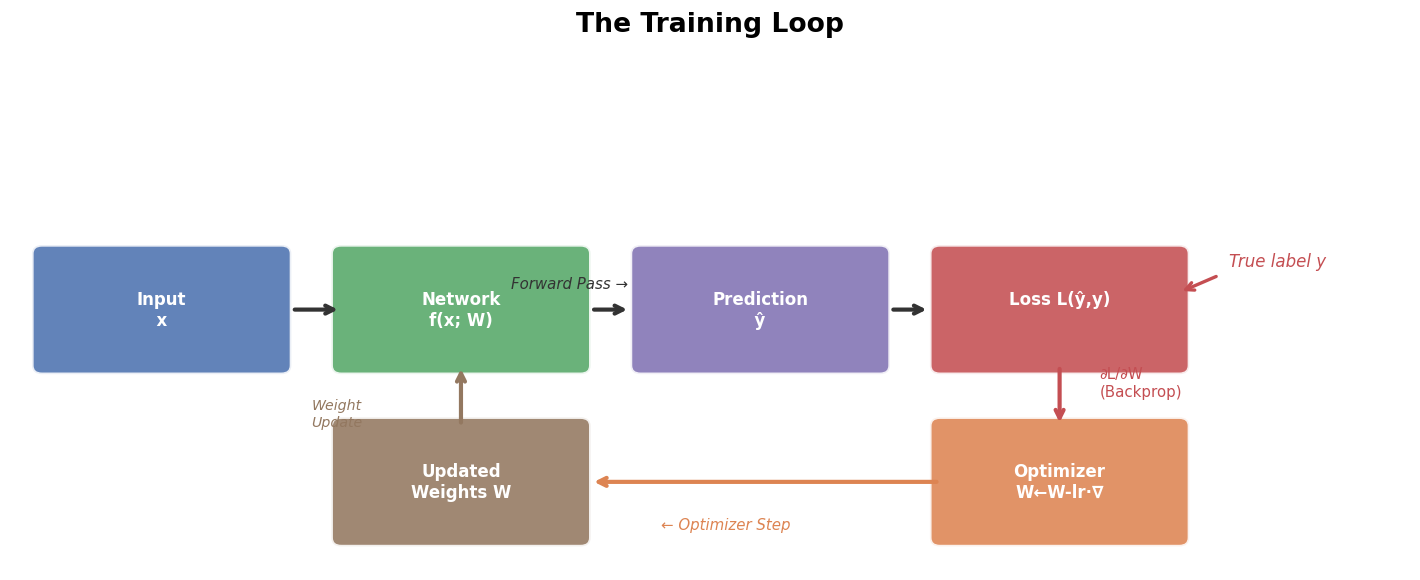

In [2]:
# Figure 1: The Training Loop — visual diagram
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)

# Boxes: (x_center, y_center, label, color)
boxes = [
    (1.5, 3, "Input\n  x  ",   "#4C72B0"),
    (4.5, 3, "Network\nf(x; W)", "#55A868"),
    (7.5, 3, "Prediction\n  ŷ  ",  "#8172B3"),
    (10.5,3, "Loss L(ŷ,y)\n        ",  "#C44E52"),
    (10.5,1, "Optimizer\nW←W-lr·∇", "#DD8452"),
    (4.5, 1, "Updated\nWeights W",  "#937860"),
]
for (x, y, lbl, col) in boxes:
    rect = FancyBboxPatch((x-1.2, y-0.65), 2.4, 1.3,
                          boxstyle="round,pad=0.1",
                          facecolor=col, edgecolor='white', linewidth=2, alpha=0.88)
    ax.add_patch(rect)
    ax.text(x, y, lbl, ha='center', va='center', color='white',
            fontsize=10, fontweight='bold')

# True label y
ax.text(12.2, 3.5, "True label y", fontsize=10, color='#C44E52', style='italic')
ax.annotate("", xy=(11.7, 3.2), xytext=(12.1, 3.4),
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=2))

# Arrows: forward pass (top)
arrow_kw = dict(arrowstyle="->", color="#333333", lw=2.5)
for x_from, x_to in [(2.8, 3.3), (5.8, 6.2), (8.8, 9.2)]:
    ax.annotate("", xy=(x_to, 3), xytext=(x_from, 3),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=2.5))

# Arrow down from Loss to Optimizer
ax.annotate("", xy=(10.5, 1.65), xytext=(10.5, 2.35),
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=2.5))
ax.text(10.9, 2.0, "∂L/∂W\n(Backprop)", fontsize=9, color="#C44E52")

# Arrow left from Optimizer to Updated Weights
ax.annotate("", xy=(5.8, 1), xytext=(9.3, 1),
            arrowprops=dict(arrowstyle="->", color="#DD8452", lw=2.5))

# Arrow up from Updated Weights to Network
ax.annotate("", xy=(4.5, 2.35), xytext=(4.5, 1.65),
            arrowprops=dict(arrowstyle="->", color="#937860", lw=2.5))

# Labels
ax.text(5.0, 3.25, "Forward Pass →", fontsize=9, color='#333', style='italic')
ax.text(6.5, 0.45, "← Optimizer Step", fontsize=9, color='#DD8452', style='italic')
ax.text(3.0, 1.65, "Weight\nUpdate", fontsize=8.5, color='#937860', style='italic')

ax.set_title("The Training Loop", fontsize=16, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 2. Loss Functions — Measuring the Mistake

> **The loss function is the compass of training.**
> It converts the difference between prediction and reality into a single scalar number.
> The optimizer then uses this number to adjust every weight in the network.

Before diving into specific losses, understand the key properties we want:
- **Differentiable** — the optimizer needs $\partial\mathcal{L}/\partial W$
- **Minimum at correct prediction** — $\mathcal{L} = 0$ when $\hat{y} = y$
- **Task-appropriate** — regression ≠ classification losses

---

### 2.1 Mean Squared Error (MSE) — The Regression Default

#### Intuition
You are a weather forecaster predicting tomorrow's temperature.
- Prediction: 25°C, Actual: 28°C → error = 3°C
- Prediction: 25°C, Actual: 32°C → error = 7°C

MSE **squares** the error so:
1. All errors are positive (no cancellation)
2. **Large errors are penalised much more** than small ones (7² = 49 vs 3² = 9)

#### Math

$$\mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

**Gradient** (what backprop actually uses):

$$\frac{\partial\mathcal{L}_{\text{MSE}}}{\partial\hat{y}_i} = \frac{2}{n}(\hat{y}_i - y_i)$$

The gradient is **proportional to the error**. Big mistake → big gradient → big correction. ✓

#### When to use MSE
| ✅ Use MSE when | ❌ Avoid MSE when |
|---------------|-----------------|
| Output is a continuous real number | Outliers are present in data |
| Errors are roughly Gaussian | You care equally about all error sizes |
| You want to heavily penalise large errors | Data has heavy-tailed noise |

#### Interview Questions: MSE
> **Q: Why does MSE penalise large errors more than small ones?**
> A: Because squaring is a convex function — doubling the error quadruples the loss. This makes MSE sensitive to outliers.

> **Q: MSE vs MAE — which would you use and why?**
> A: MSE when large errors are critically bad (e.g., financial forecasting). MAE when outliers are common and you want a robust loss.

> **Q: What is the gradient of MSE and why is its magnitude useful?**
> A: $2(\hat{y}-y)/n$. The magnitude scales with error size — large errors produce large gradients, naturally driving faster correction.


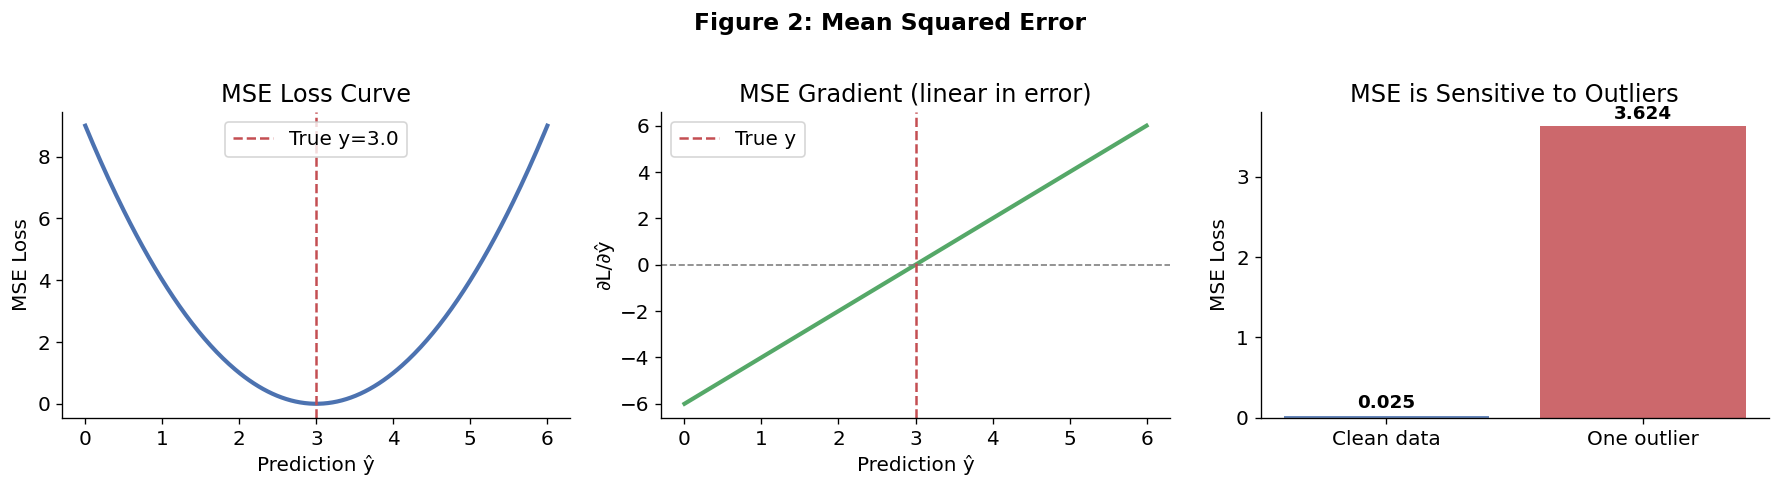

MSE (clean):   0.0250
MSE (outlier): 3.6240  — 145.0x larger due to 1 outlier!


In [3]:
# Figure 2: MSE Loss — shape, gradient, effect of outlier
np.random.seed(42)
n = 10
y_true = 3.0
y_pred_range = np.linspace(0, 6, 300)
mse = (y_pred_range - y_true)**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: MSE curve ──
axes[0].plot(y_pred_range, mse, color='#4C72B0', lw=2.5)
axes[0].axvline(y_true, color='#C44E52', ls='--', lw=1.5, label=f'True y={y_true}')
axes[0].set_xlabel('Prediction ŷ'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('MSE Loss Curve'); axes[0].legend()

# ── Plot 2: Gradient of MSE ──
grad_mse = 2 * (y_pred_range - y_true)
axes[1].plot(y_pred_range, grad_mse, color='#55A868', lw=2.5)
axes[1].axhline(0, color='grey', ls='--', lw=1)
axes[1].axvline(y_true, color='#C44E52', ls='--', lw=1.5, label='True y')
axes[1].set_xlabel('Prediction ŷ'); axes[1].set_ylabel('∂L/∂ŷ')
axes[1].set_title('MSE Gradient (linear in error)'); axes[1].legend()

# ── Plot 3: Effect of a single outlier ──
preds_clean   = np.array([2.8, 3.1, 2.9, 3.2, 3.0, 2.7, 3.1, 3.0, 3.2, 2.9])
preds_outlier = preds_clean.copy(); preds_outlier[-1] = 9.0   # one outlier

mse_clean   = np.mean((preds_clean   - y_true)**2)
mse_outlier = np.mean((preds_outlier - y_true)**2)

axes[2].bar(['Clean data', 'One outlier'], [mse_clean, mse_outlier],
            color=['#4C72B0','#C44E52'], alpha=0.85)
axes[2].set_ylabel('MSE Loss'); axes[2].set_title('MSE is Sensitive to Outliers')
for i,(v) in enumerate([mse_clean, mse_outlier]):
    axes[2].text(i, v + 0.1, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Figure 2: Mean Squared Error', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"MSE (clean):   {mse_clean:.4f}")
print(f"MSE (outlier): {mse_outlier:.4f}  — {mse_outlier/mse_clean:.1f}x larger due to 1 outlier!")


### 2.2 Mean Absolute Error (MAE) — Robust to Outliers

#### Intuition
Same dart analogy — but now you measure the **actual distance** from the bullseye, not its square.
A 10cm miss counts as exactly twice a 5cm miss. No dramatic penalty inflation.

This makes MAE **robust**: one wildly wrong prediction doesn't dominate the loss.

#### Math

$$\mathcal{L}_{\text{MAE}} = \frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i - y_i|$$

**Gradient:**

$$\frac{\partial\mathcal{L}_{\text{MAE}}}{\partial\hat{y}_i} = \frac{1}{n}\cdot\text{sign}(\hat{y}_i - y_i)$$

Notice: the gradient is **constant** — it's always $\pm 1/n$ regardless of how wrong the prediction is.

#### The Catch — Non-differentiable at 0
At $\hat{y}_i = y_i$ exactly, the absolute value has no derivative (the "kink").
In practice, we use a **subgradient** of 0 at that point, which is fine numerically.
But the constant gradient means MAE can **oscillate** near the minimum — it always takes the same step size regardless of closeness.

#### When to use MAE
| ✅ Use MAE when | ❌ Avoid MAE when |
|---------------|-----------------|
| Data has outliers | You want gradient magnitude to reflect error size |
| All errors equally important | The kink at 0 causes numerical issues in your solver |
| Median regression desired | You need a smooth, twice-differentiable loss |

#### Interview Questions: MAE
> **Q: Why is MAE more robust than MSE to outliers?**
> A: MAE's gradient is constant (sign of error), so even a massive outlier contributes only $\pm 1/n$ to the gradient, not a quadratically large gradient like MSE.

> **Q: What is the problem with MAE near the minimum?**
> A: The gradient doesn't decay to 0 as error decreases — it stays $\pm 1/n$. This causes oscillation around the minimum; the optimizer overshoots repeatedly.

> **Q: Which loss does MAE minimise at the population level?**
> A: MAE minimises the **conditional median** of $y|x$, while MSE minimises the **conditional mean**.


C:\Users\23add\AppData\Local\Temp\ipykernel_15964\4092503718.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(list(losses.keys()), rotation=15, ha='right')


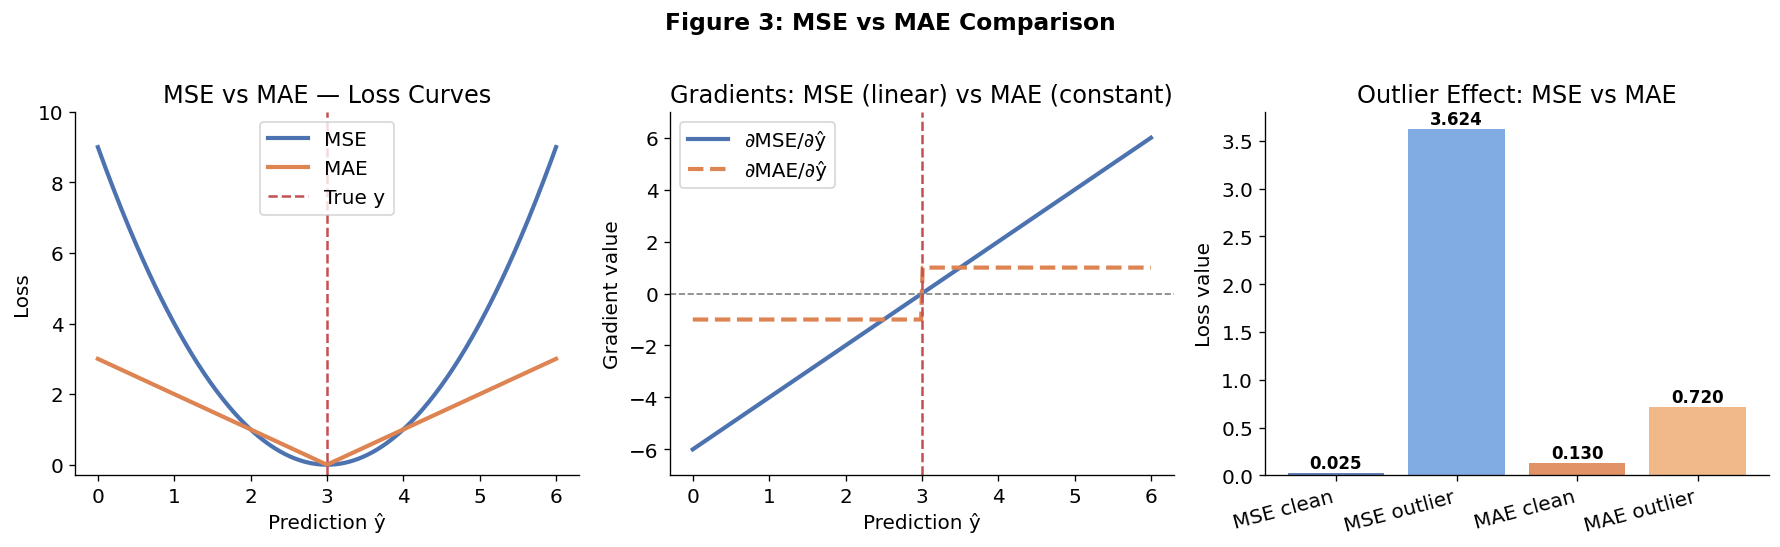

In [4]:
# Figure 3: MAE vs MSE — loss curves, gradients, and outlier robustness
y_true = 3.0
y_pred_range = np.linspace(0, 6, 300)

mse  = (y_pred_range - y_true)**2
mae  = np.abs(y_pred_range - y_true)
grad_mse = 2 * (y_pred_range - y_true)
grad_mae = np.sign(y_pred_range - y_true)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Loss curves ──
axes[0].plot(y_pred_range, mse, label='MSE', lw=2.5, color='#4C72B0')
axes[0].plot(y_pred_range, mae, label='MAE', lw=2.5, color='#DD8452')
axes[0].axvline(y_true, color='#C44E52', ls='--', lw=1.5, label='True y')
axes[0].set_xlabel('Prediction ŷ'); axes[0].set_ylabel('Loss')
axes[0].set_title('MSE vs MAE — Loss Curves'); axes[0].legend()
axes[0].set_ylim(-0.3, 10)

# ── Plot 2: Gradients ──
axes[1].plot(y_pred_range, grad_mse, label='∂MSE/∂ŷ', lw=2.5, color='#4C72B0')
axes[1].plot(y_pred_range, grad_mae, label='∂MAE/∂ŷ', lw=2.5, color='#DD8452', ls='--')
axes[1].axhline(0, color='grey', ls='--', lw=1)
axes[1].axvline(y_true, color='#C44E52', ls='--', lw=1.5)
axes[1].set_xlabel('Prediction ŷ'); axes[1].set_ylabel('Gradient value')
axes[1].set_title('Gradients: MSE (linear) vs MAE (constant)')
axes[1].legend(); axes[1].set_ylim(-7, 7)

# ── Plot 3: Outlier robustness ──
preds_clean   = np.array([2.8, 3.1, 2.9, 3.2, 3.0, 2.7, 3.1, 3.0, 3.2, 2.9])
preds_outlier = preds_clean.copy(); preds_outlier[-1] = 9.0

losses = {
    'MSE clean':   np.mean((preds_clean - y_true)**2),
    'MSE outlier': np.mean((preds_outlier - y_true)**2),
    'MAE clean':   np.mean(np.abs(preds_clean - y_true)),
    'MAE outlier': np.mean(np.abs(preds_outlier - y_true)),
}
colors = ['#4C72B0','#6fa0e0','#DD8452','#f0b07a']
bars = axes[2].bar(list(losses.keys()), list(losses.values()), color=colors, alpha=0.88)
axes[2].set_ylabel('Loss value'); axes[2].set_title('Outlier Effect: MSE vs MAE')
axes[2].set_xticklabels(list(losses.keys()), rotation=15, ha='right')
for bar, val in zip(bars, losses.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Figure 3: MSE vs MAE Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 2.3 Huber Loss — The Best of Both Worlds

#### Intuition
MSE's problem: explodes with outliers.
MAE's problem: constant gradient, oscillates near minimum.

Huber loss solves this with a **two-regime approach**:
- **Small errors** (|error| ≤ δ): behave like MSE → smooth gradient, fast convergence near minimum
- **Large errors** (|error| > δ): behave like MAE → robust to outliers

Think of it as "MSE up close, MAE from far away."

#### Math

$$\mathcal{L}_{\delta}(\hat{y}, y) = \begin{cases}
\frac{1}{2}(\hat{y} - y)^2 & \text{if } |\hat{y} - y| \leq \delta \\
\delta \left(|\hat{y} - y| - \frac{\delta}{2}\right) & \text{otherwise}
\end{cases}$$

**Gradient:**

$$\frac{\partial\mathcal{L}_{\delta}}{\partial\hat{y}} = \begin{cases}
(\hat{y} - y) & \text{if } |\hat{y} - y| \leq \delta \\
\delta \cdot \text{sign}(\hat{y} - y) & \text{otherwise}
\end{cases}$$

Key: the gradient is **everywhere continuous** (no kink), and **bounded** by $\delta$.

#### The δ hyperparameter
- $\delta$ is the threshold separating the MSE and MAE regimes
- Small $\delta$ → more like MAE (robust, but slow near min)
- Large $\delta$ → more like MSE (fast near min, but outlier-sensitive)
- Common default: $\delta = 1.0$

#### When to use Huber Loss
| ✅ Use Huber when |
|-----------------|
| Regression with some outliers present |
| You want smooth gradients near the minimum (unlike MAE) |
| You want bounded gradients for large errors (unlike MSE) |
| Object detection (SSD, Faster-RCNN use Smooth L1 = Huber with δ=1) |

#### Interview Questions: Huber
> **Q: How does Huber loss combine MSE and MAE?**
> A: Quadratic (MSE-like) for small errors, linear (MAE-like) for large errors. The threshold δ controls the switchover point.

> **Q: Why is Huber preferred in object detection?**
> A: Bounding box regression has occasional large errors (misaligned anchors). MAE-like robustness for those, MSE-like precision near the target.

> **Q: What happens when δ → ∞ and δ → 0?**
> A: δ → ∞: pure MSE. δ → 0: pure MAE (scaled). Huber interpolates between them.

> **Bonus: Log-Cosh Loss**
> An alternative to Huber is **Log-Cosh**. It computes `log(cosh(prediction - true))`. It behaves exactly like MSE for small errors and like MAE for large errors, but unlike Huber, it is infinitely differentiable everywhere and **doesn't require tuning a hyperparameter** (like delta in Huber).


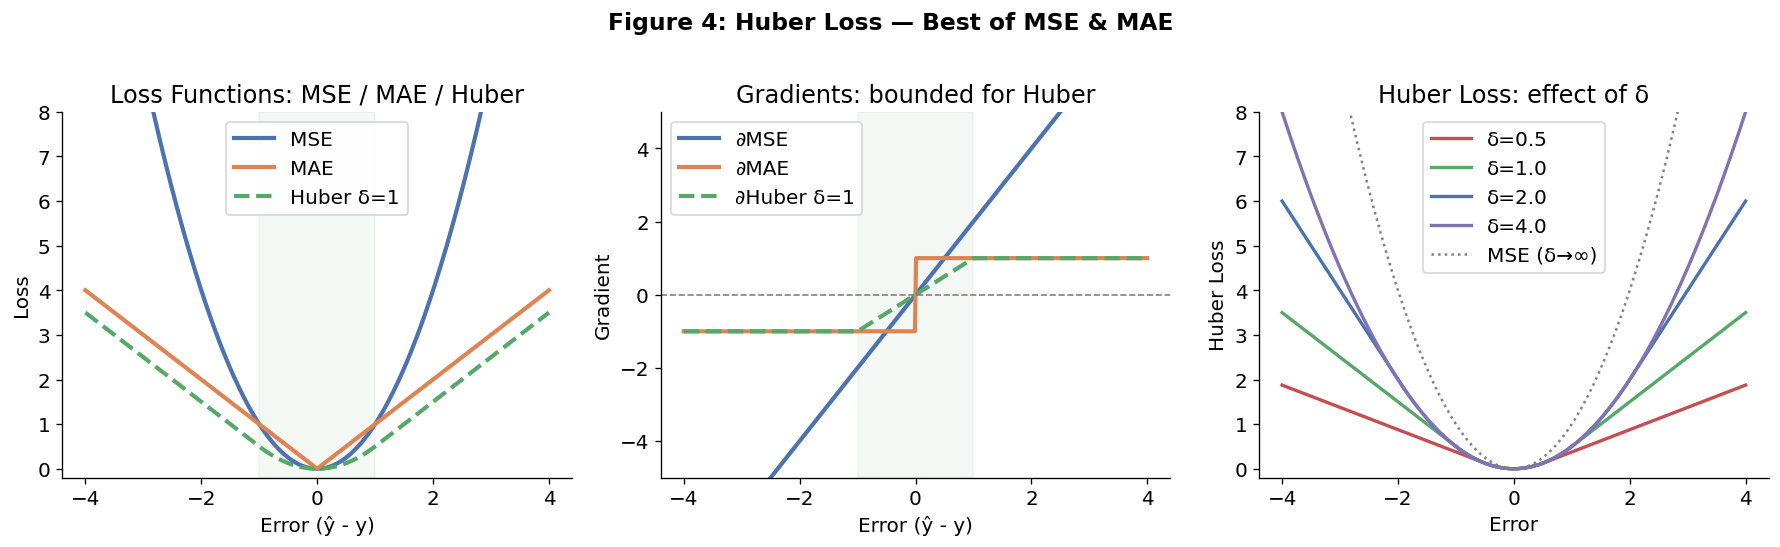

In [5]:
# Figure 4: Huber Loss — 3-way comparison MSE / MAE / Huber
y_true = 0.0
err = np.linspace(-4, 4, 400)

def huber(err, delta=1.0):
    return np.where(np.abs(err) <= delta,
                    0.5 * err**2,
                    delta * (np.abs(err) - 0.5 * delta))

def huber_grad(err, delta=1.0):
    return np.where(np.abs(err) <= delta, err, delta * np.sign(err))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Loss comparison ──
axes[0].plot(err, err**2,              label='MSE',       lw=2.5, color='#4C72B0')
axes[0].plot(err, np.abs(err),         label='MAE',       lw=2.5, color='#DD8452')
axes[0].plot(err, huber(err, delta=1), label='Huber δ=1', lw=2.5, color='#55A868', ls='--')
axes[0].set_xlabel('Error (ŷ - y)'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Functions: MSE / MAE / Huber'); axes[0].legend()
axes[0].set_ylim(-0.2, 8)

# ── Plot 2: Gradient comparison ──
axes[1].plot(err, 2*err,                   label='∂MSE',       lw=2.5, color='#4C72B0')
axes[1].plot(err, np.sign(err),            label='∂MAE',       lw=2.5, color='#DD8452')
axes[1].plot(err, huber_grad(err, delta=1),label='∂Huber δ=1', lw=2.5, color='#55A868', ls='--')
axes[1].axhline(0, color='grey', ls='--', lw=1)
axes[1].set_xlabel('Error (ŷ - y)'); axes[1].set_ylabel('Gradient')
axes[1].set_title('Gradients: bounded for Huber'); axes[1].legend()
axes[1].set_ylim(-5, 5)

# ── Plot 3: Effect of different delta values ──
for d, col in [(0.5, '#C44E52'), (1.0, '#55A868'), (2.0, '#4C72B0'), (4.0, '#8172B3')]:
    axes[2].plot(err, huber(err, d), label=f'δ={d}', lw=2, color=col)
axes[2].plot(err, err**2, label='MSE (δ→∞)', lw=1.5, color='grey', ls=':')
axes[2].set_xlabel('Error'); axes[2].set_ylabel('Huber Loss')
axes[2].set_title('Huber Loss: effect of δ'); axes[2].legend()
axes[2].set_ylim(-0.2, 8)

# Shade MSE vs MAE region
for ax in axes[:2]:
    ax.axvspan(-1, 1, alpha=0.07, color='#55A868', label='MSE regime')

plt.suptitle('Figure 4: Huber Loss — Best of MSE & MAE', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



---

### Why MSE Fails for Classification (The Non-Convex Landscape)

**Intuition:**
If you use MSE for classification, placing a prediction of `0.0001` when the true label is `1` means the error is almost 1. However, since the neural network output usually passes through a Sigmoid or Softmax activation function to turn raw logits into probabilities (between 0 and 1), the gradient of that activation function near 0 or 1 is extremely flat.

**The Problem:**
If your network makes a confident *wrong* prediction (e.g., outputs `0.001` when truth is `1`), the MSE loss is high, but the *gradient* flowing backward is close to zero because the sigmoid curve is flat at `0.001`. The network is "stuck" and learns very slowly. Cross-Entropy Loss fixes this by taking the logarithm, which cancels out the flat gradient of the sigmoid/softmax and restores a steep learning curve for confident wrong predictions!

### 2.4 Binary Cross-Entropy (BCE) — The Classification Loss

#### Intuition
For regression we measure distance. For **binary classification** (spam/not-spam, cat/dog),
the network outputs a **probability** between 0 and 1.

Imagine a weather app saying: "90% chance of rain." If it rains, great prediction.
If it doesn't rain — the app was very confident and very wrong. We should penalise this heavily.

BCE does exactly that: **being confidently wrong is catastrophically penalised.**

#### Setup
- Network outputs $\hat{y} = \sigma(z) \in (0, 1)$ (sigmoid activation)
- True label $y \in \{0, 1\}$

#### Math

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{n}\sum_{i=1}^{n}\left[ y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right]$$

Breaking it down:
- When $y_i = 1$: loss = $-\log(\hat{y}_i)$ → penalise low predicted probability
- When $y_i = 0$: loss = $-\log(1-\hat{y}_i)$ → penalise high predicted probability

**Gradient** (with sigmoid output):

$$\frac{\partial\mathcal{L}_{\text{BCE}}}{\partial z_i} = \hat{y}_i - y_i$$

Elegantly simple: gradient = prediction error. This is why sigmoid + BCE is paired.

#### The Numerical Stability Issue
Direct $\log(\hat{y})$ is undefined at 0. In practice:
- Clamp predictions: $\hat{y} = \text{clip}(\hat{y},\, \epsilon,\, 1-\epsilon)$
- Or use **log-sum-exp trick** (what PyTorch does internally with `BCEWithLogitsLoss`)

> **Always prefer `BCEWithLogitsLoss` over `BCELoss` in PyTorch** — it applies sigmoid and log in one numerically stable step.

#### Interview Questions: BCE
> **Q: Why use cross-entropy for classification instead of MSE?**
> A: With MSE + sigmoid output, gradients vanish when predictions are saturated (wrong and confident). BCE's log gradient is still large in that case, causing faster learning.

> **Q: What does BCE measure in terms of information theory?**
> A: It's the **cross-entropy** between the true distribution and predicted distribution — measuring extra bits needed to encode y using ŷ instead of the true distribution.

> **Q: Why does PyTorch have `BCELoss` and `BCEWithLogitsLoss`?**
> A: `BCEWithLogitsLoss` combines sigmoid + BCE in one numerically stable operation using the log-sum-exp trick. Always prefer it.

> **Q: What is the gradient of BCE + sigmoid output?**
> A: $\hat{y}_i - y_i$ — prediction error. Elegant and computationally clean.


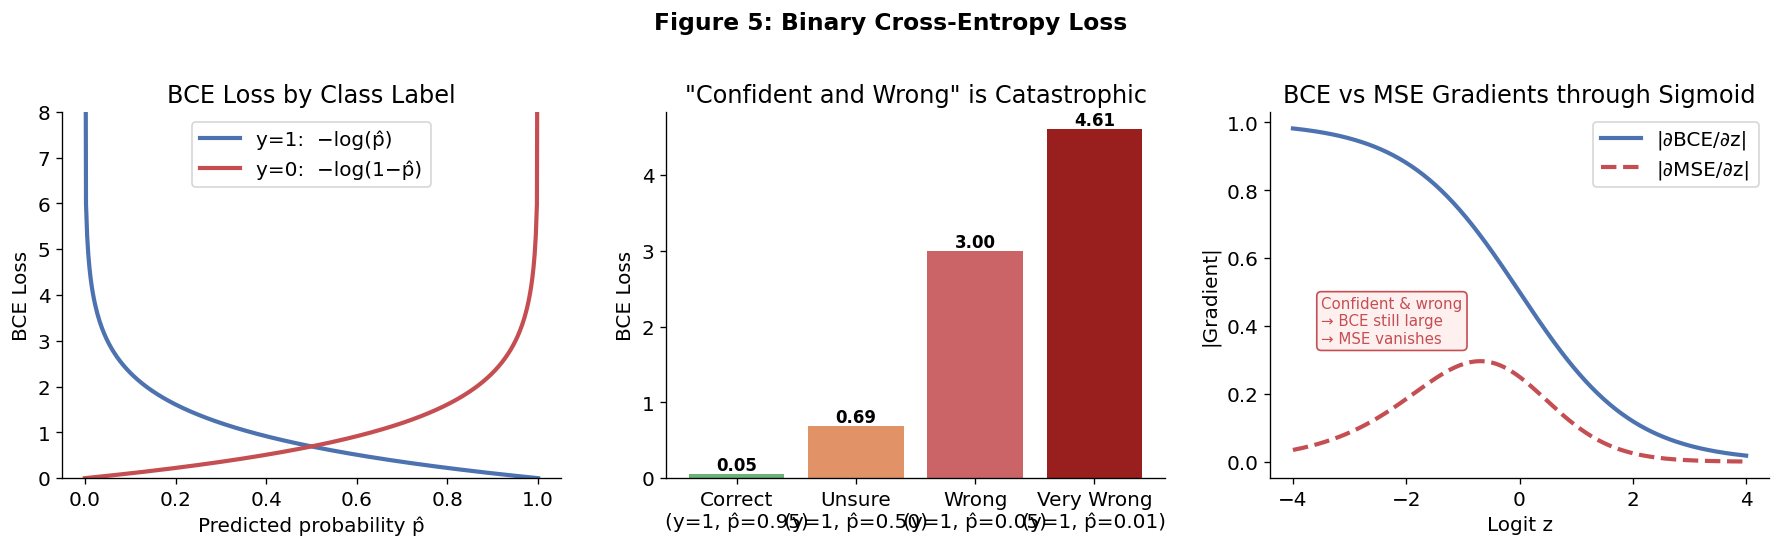

BCEWithLogitsLoss (stable): 2.263441
BCELoss (manual sigmoid):   2.263441
→ Same value, but BCEWithLogitsLoss is numerically safer!


In [6]:
# Figure 5: Binary Cross-Entropy — loss curve, confident-wrong penalty, PyTorch demo
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

p = np.linspace(1e-7, 1-1e-7, 400)   # predicted probability

# ── Plot 1: BCE curve for y=1 and y=0 ──
axes[0].plot(p, -np.log(p),   label='y=1:  −log(p̂)',   lw=2.5, color='#4C72B0')
axes[0].plot(p, -np.log(1-p), label='y=0:  −log(1−p̂)', lw=2.5, color='#C44E52')
axes[0].set_xlabel('Predicted probability p̂'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('BCE Loss by Class Label'); axes[0].legend(); axes[0].set_ylim(0, 8)

# ── Plot 2: "Confident and wrong" penalty ──
scenarios = {
    'Correct\n(y=1, p̂=0.95)': -np.log(0.95),
    'Unsure\n(y=1, p̂=0.50)': -np.log(0.50),
    'Wrong\n(y=1, p̂=0.05)': -np.log(0.05),
    'Very Wrong\n(y=1, p̂=0.01)': -np.log(0.01),
}
colors2 = ['#55A868','#DD8452','#C44E52','#8B0000']
bars = axes[1].bar(list(scenarios.keys()), list(scenarios.values()), color=colors2, alpha=0.88)
axes[1].set_ylabel('BCE Loss'); axes[1].set_title('"Confident and Wrong" is Catastrophic')
for bar, val in zip(bars, scenarios.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# ── Plot 3: BCE vs MSE gradient behaviour ──
errors = np.linspace(-4, 4, 300)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
pred = sigmoid(errors)

# BCE+sigmoid grad = pred - y; for y=1: pred - 1
grad_bce = pred - 1.0          # y=1 case
grad_mse = 2*(pred - 1)*(pred*(1-pred))   # MSE + sigmoid chain rule

axes[2].plot(errors, np.abs(grad_bce), label='|∂BCE/∂z|', lw=2.5, color='#4C72B0')
axes[2].plot(errors, np.abs(grad_mse), label='|∂MSE/∂z|', lw=2.5, color='#C44E52', ls='--')
axes[2].set_xlabel('Logit z'); axes[2].set_ylabel('|Gradient|')
axes[2].set_title('BCE vs MSE Gradients through Sigmoid')
axes[2].legend()
axes[2].text(-3.5, 0.35, 'Confident & wrong\n→ BCE still large\n→ MSE vanishes',
             fontsize=9, color='#C44E52',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff0f0', edgecolor='#C44E52'))

plt.suptitle('Figure 5: Binary Cross-Entropy Loss', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── PyTorch comparison: BCELoss vs BCEWithLogitsLoss ──
logits = torch.tensor([-3.0, 0.0, 3.0])
labels = torch.tensor([1.0,  1.0, 0.0])

bce_safe = nn.BCEWithLogitsLoss()(logits, labels)
bce_manual = nn.BCELoss()(torch.sigmoid(logits), labels)

print(f"BCEWithLogitsLoss (stable): {bce_safe.item():.6f}")
print(f"BCELoss (manual sigmoid):   {bce_manual.item():.6f}")
print("→ Same value, but BCEWithLogitsLoss is numerically safer!")


### 2.5 Categorical Cross-Entropy (CCE) & NLL Loss

#### Intuition
Now instead of binary classification (2 classes), we have **K classes** (e.g., cat, dog, bird, fish).

The network outputs a vector of K probabilities via **softmax**: $[0.7, 0.1, 0.15, 0.05]$

CCE asks: *how much probability mass did you assign to the true class?*
- If you put 0.9 on the right class → low loss
- If you put 0.05 on the right class → high loss

#### Math

**Softmax (converts logits to probabilities):**

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

**Categorical Cross-Entropy:**

$$\mathcal{L}_{\text{CCE}} = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik}\log(\hat{y}_{ik})$$

For **one-hot labels** (only one $y_{ik}=1$, rest 0), this simplifies to:

$$\mathcal{L}_{\text{CCE}} = -\frac{1}{n}\sum_{i=1}^{n}\log(\hat{y}_{i,\text{true}})$$

We only look at the probability assigned to the **true class**. All other terms vanish.

#### NLL Loss (Negative Log-Likelihood)
PyTorch's `NLLLoss` expects **log-probabilities** as input (from `log_softmax`):

$$\mathcal{L}_{\text{NLL}} = -\frac{1}{n}\sum_{i=1}^{n} \log\hat{y}_{i,\text{true}}$$

**`CrossEntropyLoss` in PyTorch = `LogSoftmax` + `NLLLoss`** (numerically stable combined op).

#### Gradient (combined Softmax + CCE)
The combined gradient is beautifully simple:

$$\frac{\partial\mathcal{L}}{\partial z_k} = \hat{y}_k - \mathbf{1}[k = \text{true class}]$$

= **predicted probability minus 1 for correct class, minus 0 for others** = prediction error vector.

#### Label Smoothing (Practical Trick)
Hard one-hot labels make the model overconfident. Instead:

$$y_{ik}^{\text{smooth}} = (1-\epsilon)\cdot y_{ik}^{\text{hard}} + \frac{\epsilon}{K}$$

PyTorch: `CrossEntropyLoss(label_smoothing=0.1)`

#### Interview Questions: CCE
> **Q: Why do we use CrossEntropyLoss instead of MSE for classification?**
> A: MSE doesn't account for the probabilistic nature of softmax outputs. CrossEntropyLoss directly maximises the log-likelihood of the true class, has better-behaved gradients through softmax, and avoids vanishing gradients.

> **Q: What is the gradient of Softmax + CrossEntropy?**
> A: $\hat{y}_k - \mathbf{1}[k=\text{true}]$ — simple prediction error. This is why softmax+CCE is the standard output layer.

> **Q: What is NLLLoss in PyTorch vs CrossEntropyLoss?**
> A: NLLLoss expects log-probabilities (after log_softmax). CrossEntropyLoss = log_softmax + NLLLoss in one stable step. Always use CrossEntropyLoss with raw logits.

> **Q: What is label smoothing and why does it help?**
> A: Replaces hard 0/1 labels with soft targets (ε/K for wrong classes, 1-ε+ε/K for true class). Prevents overconfidence and improves calibration and generalisation.


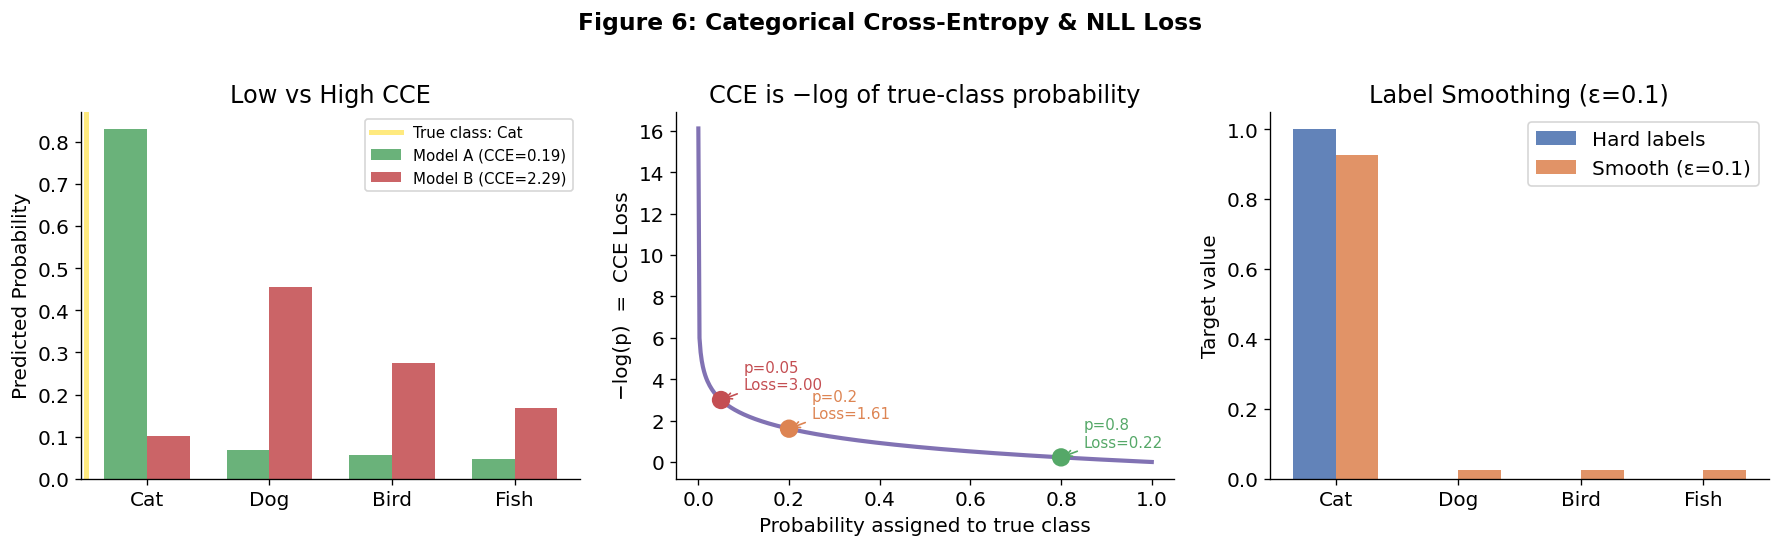

CrossEntropyLoss (hard labels):    1.2366
CrossEntropyLoss (label_smooth=0.1): 1.3004

Batch item 1 probs: [0.83  0.068 0.056 0.046]  → loss=0.1859
Batch item 2 probs: [0.102 0.455 0.276 0.167]  → loss=2.2873


In [7]:
# Figure 6: Categorical Cross-Entropy — softmax distribution + loss sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
classes = ['Cat', 'Dog', 'Bird', 'Fish']
K = 4

# ── Plot 1: Two softmax distributions, CCE comparison ──
# Model A: correct class (Cat, idx 0) gets 0.8
logits_good = np.array([3.0, 0.5, 0.3, 0.1])
# Model B: correct class (Cat) gets 0.15
logits_bad  = np.array([0.5, 2.0, 1.5, 1.0])

def softmax(z):
    e = np.exp(z - z.max())
    return e / e.sum()

probs_good = softmax(logits_good)
probs_bad  = softmax(logits_bad)

x = np.arange(K)
w = 0.35
axes[0].bar(x - w/2, probs_good, w, label=f'Model A (CCE={-np.log(probs_good[0]):.2f})',
            color='#55A868', alpha=0.88)
axes[0].bar(x + w/2, probs_bad,  w, label=f'Model B (CCE={-np.log(probs_bad[0]):.2f})',
            color='#C44E52', alpha=0.88)
axes[0].set_xticks(x); axes[0].set_xticklabels(classes)
axes[0].set_ylabel('Predicted Probability'); axes[0].set_title('Low vs High CCE')
axes[0].axvline(-0.5+0.0001, color='gold', lw=3, alpha=0.5, label='True class: Cat')
axes[0].legend(fontsize=9)

# ── Plot 2: CCE as function of true-class probability ──
p_true = np.linspace(1e-7, 1-1e-7, 400)
cce    = -np.log(p_true)
axes[1].plot(p_true, cce, color='#8172B3', lw=2.5)
axes[1].scatter([0.8, 0.2, 0.05], [-np.log(x) for x in [0.8,0.2,0.05]],
               s=100, zorder=5, color=['#55A868','#DD8452','#C44E52'])
for p,c in zip([0.8,0.2,0.05],['#55A868','#DD8452','#C44E52']):
    axes[1].annotate(f'p={p}\nLoss={-np.log(p):.2f}',
                     xy=(p, -np.log(p)), xytext=(p+0.05, -np.log(p)+0.5),
                     fontsize=9, color=c, arrowprops=dict(arrowstyle='->', color=c))
axes[1].set_xlabel('Probability assigned to true class')
axes[1].set_ylabel('−log(p)  =  CCE Loss')
axes[1].set_title('CCE is −log of true-class probability')

# ── Plot 3: Label smoothing effect ──
eps = 0.1
y_hard   = np.array([1.0, 0.0, 0.0, 0.0])
y_smooth = (1-eps)*y_hard + eps/K

axes[2].bar(x - w/2, y_hard,   w, label='Hard labels', color='#4C72B0', alpha=0.88)
axes[2].bar(x + w/2, y_smooth, w, label=f'Smooth (ε={eps})', color='#DD8452', alpha=0.88)
axes[2].set_xticks(x); axes[2].set_xticklabels(classes)
axes[2].set_ylabel('Target value'); axes[2].set_title('Label Smoothing (ε=0.1)')
axes[2].legend()

plt.suptitle('Figure 6: Categorical Cross-Entropy & NLL Loss', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── PyTorch CrossEntropyLoss demo ──
logits_t = torch.tensor([[3.0, 0.5, 0.3, 0.1],   # batch item 1 — confident correct
                          [0.5, 2.0, 1.5, 1.0]])   # batch item 2 — confident wrong
targets  = torch.tensor([0, 0])   # both should be class 0 (Cat)

loss_hard   = nn.CrossEntropyLoss()(logits_t, targets)
loss_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)(logits_t, targets)

print(f"CrossEntropyLoss (hard labels):    {loss_hard.item():.4f}")
print(f"CrossEntropyLoss (label_smooth=0.1): {loss_smooth.item():.4f}")

# Show softmax probs
probs_t = torch.softmax(logits_t, dim=1)
print(f"\nBatch item 1 probs: {probs_t[0].detach().numpy().round(3)}  → loss={-np.log(probs_t[0][0].item()):.4f}")
print(f"Batch item 2 probs: {probs_t[1].detach().numpy().round(3)}  → loss={-np.log(probs_t[1][0].item()):.4f}")


### 2.6 Bonus: Focal Loss — Handling Extreme Class Imbalance

#### Intuition
Imagine a dataset where 99% of images are background, and 1% contains a tumor. Standard Cross-Entropy will easily classify the background and learn to push the loss to a small value. However, 99% of tiny losses sum up to a massive gradient that overwhelms the 1% of tumor cases.
**Focal Loss** adds a focusing parameter $\gamma$ that smoothly down-weights the loss for well-classified examples. If the model is 95% confident about a background image, Focal Loss forces the loss to essentially zero, so the optimizer focuses entirely on the hard, rare tumor images.

#### Math
$$\text{Focal Loss} = -(1 - p_t)^\gamma \log(p_t)$$
Where $p_t$ is the predicted probability of the true class. If $p_t \approx 1$ (easy example), the term $(1 - p_t)^\gamma$ approaches 0, suppressing the loss.


### 2.7 Loss Landscape — Visualising the Terrain the Optimizer Must Navigate

#### Intuition
Think of the loss function as a **mountain landscape**.
The optimizer is a hiker trying to reach the **lowest valley** (minimum loss).

Key features of this landscape:
- **Global minimum** — the absolute best solution (rarely found)
- **Local minima** — valleys that aren't the best, but look like the best locally
- **Saddle points** — flat regions where gradient is 0 in some directions but not others
- **Plateaus** — flat regions where gradients are tiny → training stalls
- **Sharp vs flat minima** — flat minima generalise better (discussed in optimizers module)

#### Why this matters
Different choices of:
- **Loss function** → changes the entire landscape shape
- **Optimizer** → determines the hiking strategy
- **Learning rate** → step size on the hike

The loss landscape for deep networks is **high dimensional** and non-convex.
We can only visualise 2D slices, but the intuition transfers.


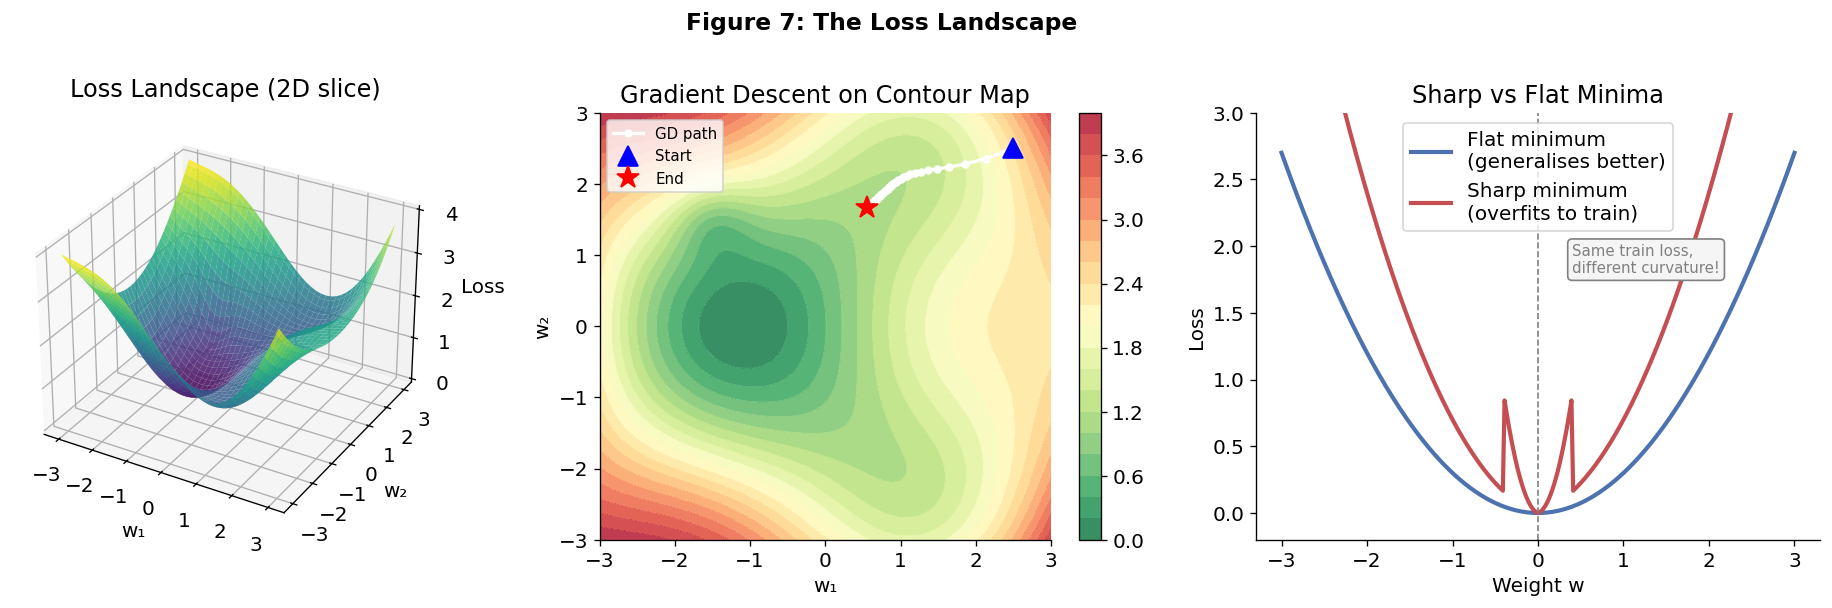

In [8]:
# Figure 7: Loss Landscape — 2D slices of different terrain features
fig = plt.figure(figsize=(16, 5))

# ── 3D surface: a simplified loss landscape ──
ax1 = fig.add_subplot(131, projection='3d')
w1 = np.linspace(-3, 3, 80)
w2 = np.linspace(-3, 3, 80)
W1, W2 = np.meshgrid(w1, w2)

# Synthetic loss with local min, global min, saddle point
L = (np.sin(W1)*np.cos(W2)*1.5 +
     0.3*W1**2 + 0.3*W2**2 +
     0.5*np.exp(-(W1+1.5)**2/0.3 - (W2-1.5)**2/0.3)*(-2))
L_norm = (L - L.min()) / (L.max() - L.min()) * 4

ax1.plot_surface(W1, W2, L_norm, cmap='viridis', alpha=0.85, linewidth=0)
ax1.set_xlabel('w₁'); ax1.set_ylabel('w₂'); ax1.set_zlabel('Loss')
ax1.set_title('Loss Landscape (2D slice)', pad=10)

# ── 2D contour with gradient descent path ──
ax2 = fig.add_subplot(132)
np.random.seed(7)
im = ax2.contourf(W1, W2, L_norm, levels=25, cmap='RdYlGn_r', alpha=0.8)
ax2.contour(W1, W2, L_norm, levels=25, colors='white', alpha=0.3, linewidths=0.4)

# Simulate a gradient descent path
path_w1, path_w2 = [2.5], [2.5]
lr_sim = 0.15
for _ in range(30):
    pw1, pw2 = path_w1[-1], path_w2[-1]
    # Numerical gradient
    gw1 = (np.sin(pw1+0.01)*np.cos(pw2) - np.sin(pw1-0.01)*np.cos(pw2)) / 0.02 * 1.5 + 0.6*pw1
    gw2 = (np.sin(pw1)*np.cos(pw2+0.01) - np.sin(pw1)*np.cos(pw2-0.01)) / 0.02 * 1.5 + 0.6*pw2
    path_w1.append(pw1 - lr_sim*gw1)
    path_w2.append(pw2 - lr_sim*gw2)

ax2.plot(path_w1, path_w2, 'w-o', ms=4, lw=2, label='GD path', zorder=5)
ax2.plot(path_w1[0], path_w2[0], 'b^', ms=12, label='Start', zorder=6)
ax2.plot(path_w1[-1], path_w2[-1], 'r*', ms=14, label='End', zorder=6)
ax2.set_xlabel('w₁'); ax2.set_ylabel('w₂')
ax2.set_title('Gradient Descent on Contour Map'); ax2.legend(fontsize=9)
plt.colorbar(im, ax=ax2)

# ── 1D slice: sharp vs flat minima ──
ax3 = fig.add_subplot(133)
w = np.linspace(-3, 3, 300)
sharp = 5*w**2 * np.where(np.abs(w) < 0.4, 1.0, 0.1) + np.abs(w)*0.2
flat  = 0.3*w**2

ax3.plot(w, flat,  lw=2.5, color='#4C72B0', label='Flat minimum\n(generalises better)')
ax3.plot(w, sharp, lw=2.5, color='#C44E52', label='Sharp minimum\n(overfits to train)')
ax3.axvline(0, color='grey', ls='--', lw=1)
ax3.set_ylim(-0.2, 3)
ax3.set_xlabel('Weight w'); ax3.set_ylabel('Loss')
ax3.set_title('Sharp vs Flat Minima'); ax3.legend()
ax3.text(0.4, 1.8, 'Same train loss,\ndifferent curvature!',
         fontsize=9, color='grey',
         bbox=dict(boxstyle='round', facecolor='#f5f5f5', edgecolor='grey'))

plt.suptitle('Figure 7: The Loss Landscape', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Loss Function Summary — Quick Reference

| Loss | Task | Formula | Outlier Robust | PyTorch |
|------|------|---------|----------------|---------|
| **MSE** | Regression | $\frac{1}{n}\sum(\hat{y}-y)^2$ | ❌ | `nn.MSELoss()` |
| **MAE** | Regression | $\frac{1}{n}\sum\|\hat{y}-y\|$ | ✅ | `nn.L1Loss()` |
| **Huber** | Regression | MSE if $\|e\|\leq\delta$ else MAE-like | ✅ Partial | `nn.HuberLoss()` |
| **BCE** | Binary Classif. | $-[y\log\hat{y}+(1-y)\log(1-\hat{y})]$ | N/A | `nn.BCEWithLogitsLoss()` |
| **CCE** | Multi-class | $-\sum y_k\log\hat{y}_k$ | N/A | `nn.CrossEntropyLoss()` |

**Golden rules:**
- Always use `BCEWithLogitsLoss` (not `BCELoss`) for binary classification
- Always use `CrossEntropyLoss` with **raw logits** (not after softmax)
- Default to **Huber** for regression when you suspect outliers
- Add `label_smoothing=0.1` to `CrossEntropyLoss` for classification tasks

### Loss Function Decision Tree Cheat Sheet

- **Is your task Regression (predicting a continuous number)?**
  - Are there big, unpredictable outliers? -> **Use MAE (L1)**
  - Do you want to heavily penalise large errors and the data is clean? -> **Use MSE (L2)**
  - Do you want the best of both? -> **Use Huber Loss** (or Log-Cosh)

- **Is your task Classification (predicting categories)?**
  - Is it binary (Yes/No)? -> **Use Binary Cross-Entropy (BCE)**
  - Is it multi-class (Cat vs Dog vs Bird)? -> **Use Categorical Cross-Entropy (CCE)**
  - Are your labels integers (0, 1, 2) instead of one-hot vectors? -> **Use Sparse CCE**
  - Is there an enormous class imbalance (e.g., 99% vs 1%)? -> **Use Focal Loss**

---

### What happens if you get it wrong?

1. **Using MSE for Classification:** Your loss landscape becomes non-convex with flat plateaus. Confident wrong predictions produce near-zero gradients (vanishing gradient problem), causing training to stall immediately.
2. **Using Cross-Entropy for Regression:** Math doesn't align. Cross-entropy expects probabilities (0 to 1). Regression outputs can be any real number.
3. **Using MAE for clean Regression with no outliers:** Your loss curve is a V-shape. When the model gets very close to the perfect prediction, the gradient doesn't shrink—it stays constant, causing the optimizer to endlessly "jump" over the minimum without settling.


---

## 3. Backpropagation — The Chain Rule Engine

> "Backpropagation is just the chain rule applied to a computational graph."
> Understanding it deeply separates practitioners from engineers who just call `.backward()`.

---

### 3.1 Forward Pass vs Backward Pass

#### Intuition: The Pipe & Echo Analogy
Imagine a signal flowing through a pipe with multiple valves:

- **Forward pass**: A signal (input data) flows *forward* through the pipe. Each valve processes it. At the end, we measure the output and compare it to what we wanted → **loss**.

- **Backward pass**: We send an "echo" back through the pipe from the error signal. Each valve learns *how much it personally contributed to the overall error* — this is its **gradient**.

The echo (gradient) shrinks or amplifies as it passes through each valve, depending on the valve's local sensitivity.

#### Math Setup

Given a network with layers $L_1, L_2, ..., L_n$:

**Forward pass** — left to right:
$$a^{(0)} = x \quad\text{(input)}$$
$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$
$$a^{(l)} = \sigma(z^{(l)})$$
$$\hat{y} = a^{(n)}, \quad \mathcal{L} = \text{Loss}(\hat{y},\, y)$$

**Backward pass** — right to left:
$$\delta^{(n)} = \frac{\partial\mathcal{L}}{\partial z^{(n)}}$$
$$\delta^{(l)} = \left(W^{(l+1)T}\delta^{(l+1)}\right) \odot \sigma'(z^{(l)})$$
$$\frac{\partial\mathcal{L}}{\partial W^{(l)}} = \delta^{(l)} \cdot (a^{(l-1)})^T$$

Where $\delta^{(l)}$ is the **error signal** at layer $l$ — how much each pre-activation contributed to the total loss.

#### What Backprop Actually Computes
For every parameter $w_{ij}^{(l)}$ in the network:

$$\frac{\partial\mathcal{L}}{\partial w_{ij}^{(l)}} = \text{"If I increase } w_{ij}^{(l)} \text{ by 1, how much does the loss change?"}$$

This tells the optimizer: *push this weight up or down, and by how much.*

> **Dynamic Programming Analogy:**
> If you calculated the derivative of the final loss with respect to the first layer's weights directly, you would evaluate the same intermediate derivatives millions of times. Backpropagation is just **Dynamic Programming (Memoization)** applied to derivatives. It starts from the end, computes the derivative, and *caches* it to be re-used by the previous layer. This reduces an exponentially complex calculation into a simple, linear one!


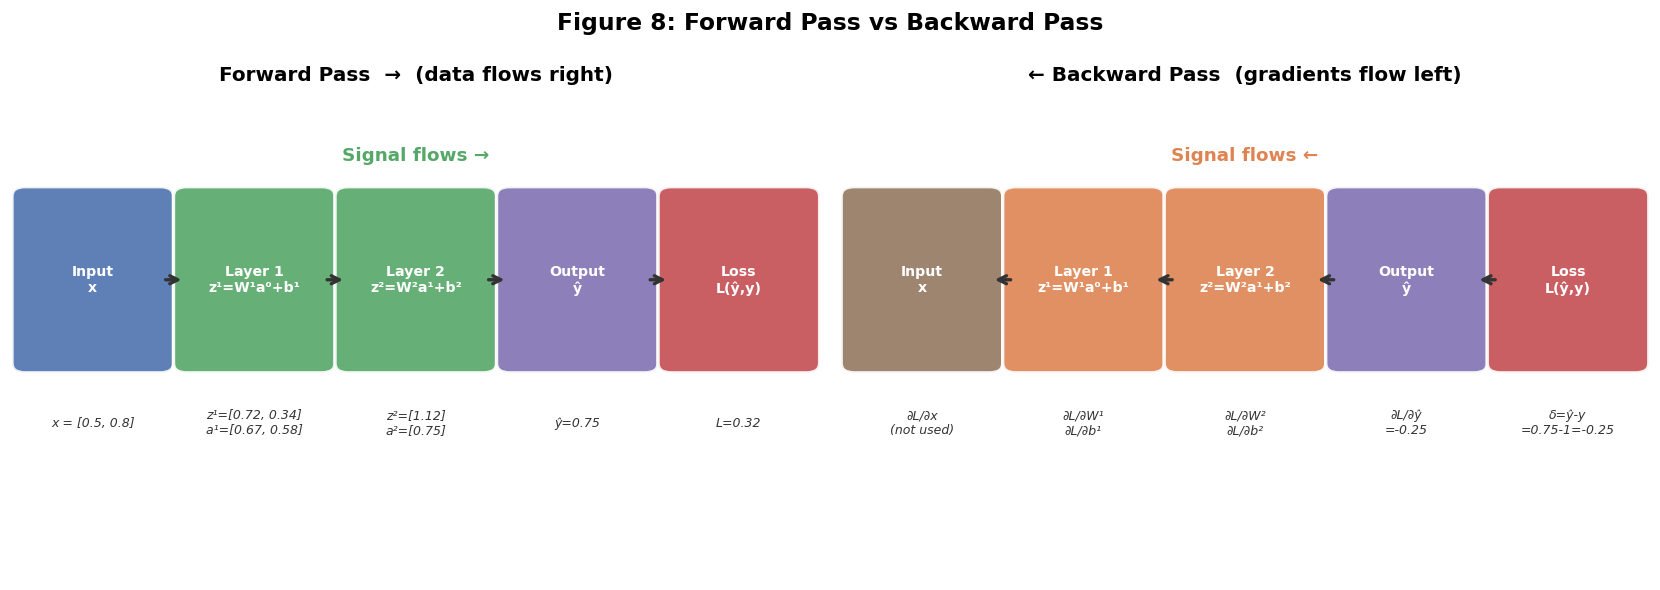

In [9]:
# Figure 8: Forward Pass (data flows right) vs Backward Pass (gradients flow left)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

layer_names  = ['Input\nx', 'Layer 1\nz¹=W¹a⁰+b¹', 'Layer 2\nz²=W²a¹+b²', 'Output\nŷ', 'Loss\nL(ŷ,y)']
forward_vals = ['x = [0.5, 0.8]', 'z¹=[0.72, 0.34]\na¹=[0.67, 0.58]', 'z²=[1.12]\na²=[0.75]', 'ŷ=0.75', 'L=0.32']
back_grads   = ['∂L/∂x\n(not used)', '∂L/∂W¹\n∂L/∂b¹', '∂L/∂W²\n∂L/∂b²', '∂L/∂ŷ\n=-0.25', 'δ=ŷ-y\n=0.75-1=-0.25']

colors_fwd  = ['#4C72B0','#55A868','#55A868','#8172B3','#C44E52']
colors_back = ['#937860','#DD8452','#DD8452','#8172B3','#C44E52']
n = len(layer_names)

for ax_idx, (ax, colors, title, vals, direction) in enumerate([
    (axes[0], colors_fwd,  'Forward Pass  →  (data flows right)', forward_vals, 1),
    (axes[1], colors_back, '← Backward Pass  (gradients flow left)', back_grads, -1)
]):
    ax.axis('off')
    ax.set_xlim(-0.5, n-0.5)
    ax.set_ylim(-1, 3)

    for i, (name, val, col) in enumerate(zip(layer_names, vals, colors)):
        rect = FancyBboxPatch((i-0.42, 0.8), 0.84, 1.4,
                              boxstyle="round,pad=0.08",
                              facecolor=col, edgecolor='white', linewidth=2, alpha=0.9)
        ax.add_patch(rect)
        ax.text(i, 1.5, name, ha='center', va='center', color='white',
                fontsize=8.5, fontweight='bold')
        ax.text(i, 0.3, val, ha='center', va='center', color='#333',
                fontsize=7.5, style='italic')

    # Arrows
    for i in range(n-1):
        x_from = i + 0.43 if direction == 1 else i + 1 - 0.43
        x_to   = i + 1 - 0.43 if direction == 1 else i + 0.43
        ax.annotate("", xy=(x_to, 1.5), xytext=(x_from, 1.5),
                    arrowprops=dict(arrowstyle="->", color="#333", lw=2))

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.text(n//2, 2.5, 'Signal flows ' + ('→' if direction==1 else '←'),
            ha='center', fontsize=11, color=colors[2], fontweight='bold')

plt.suptitle('Figure 8: Forward Pass vs Backward Pass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.2 The Chain Rule — The Core Mechanism

#### Intuition: The Domino Chain
If pressing button A moves lever B, and lever B pushes piston C — then pressing button A moves piston C.
The **chain rule** quantifies exactly *how much* A affects C, given how much A affects B, and B affects C.

$$\frac{\partial C}{\partial A} = \frac{\partial C}{\partial B} \cdot \frac{\partial B}{\partial A}$$

In neural networks, the "buttons" are weights, the "pistons" are the loss, and there are many levers (layers) in between.

#### Math: Chain Rule for Composition of Functions

For $\mathcal{L} = f(g(h(x)))$:

$$\frac{d\mathcal{L}}{dx} = \frac{\partial f}{\partial g} \cdot \frac{\partial g}{\partial h} \cdot \frac{\partial h}{\partial x}$$

**For a 2-layer network** — tracing $\frac{\partial\mathcal{L}}{\partial W^{(1)}}$:

$$\frac{\partial\mathcal{L}}{\partial W^{(1)}} =
\underbrace{\frac{\partial\mathcal{L}}{\partial \hat{y}}}_{\text{loss grad}}
\cdot
\underbrace{\frac{\partial\hat{y}}{\partial z^{(2)}}}_{\sigma'(z^{(2)})}
\cdot
\underbrace{\frac{\partial z^{(2)}}{\partial a^{(1)}}}_{W^{(2)}}
\cdot
\underbrace{\frac{\partial a^{(1)}}{\partial z^{(1)}}}_{\sigma'(z^{(1)})}
\cdot
\underbrace{\frac{\partial z^{(1)}}{\partial W^{(1)}}}_{a^{(0)} = x}$$

Each term is a **local gradient** easily computed at that layer. Backprop chains them together.

#### Key Insight: Local Gradients + Global Chain
Each layer only needs to know:
1. The gradient arriving from the **right** (from the loss)
2. Its own **local gradient** (of its output w.r.t. its input)

It multiplies them and passes the result to the **left**. This is why backprop is efficient —
each layer is an independent multiplier in the chain.

| Layer | What it computes locally |
|-------|--------------------------|
| Linear $z = Wx + b$ | $\partial z/\partial W = x^T$, $\partial z/\partial x = W^T$ |
| ReLU $a = \max(0,z)$ | $\partial a/\partial z = \mathbf{1}[z > 0]$ |
| Sigmoid $a = \sigma(z)$ | $\partial a/\partial z = \sigma(z)(1-\sigma(z))$ |
| MSE $\mathcal{L} = (a-y)^2$ | $\partial\mathcal{L}/\partial a = 2(a-y)$ |


C:\Users\23add\AppData\Local\Temp\ipykernel_15964\697129604.py:43: UserWarning: Glyph 120783 (\N{MATHEMATICAL BOLD DIGIT ONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\23add\workspace\deeplearning\envNote\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 120783 (\N{MATHEMATICAL BOLD DIGIT ONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


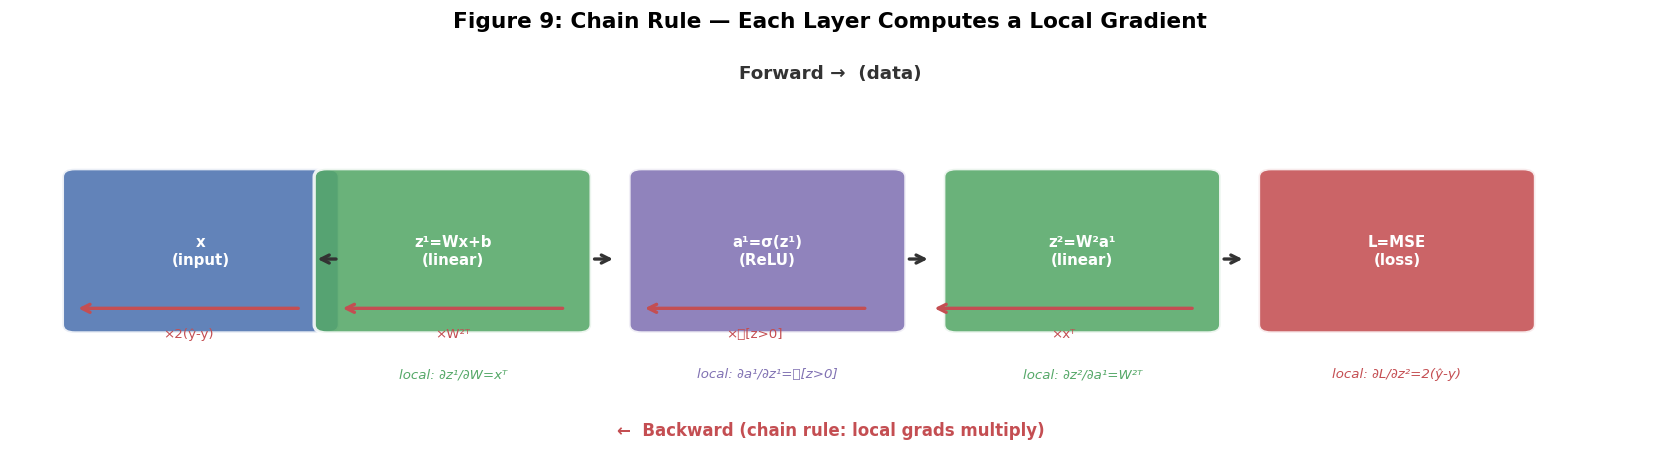

In [10]:
# Figure 9: Chain rule — local gradients multiplied along the path
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off'); ax.set_xlim(0, 13); ax.set_ylim(0, 5)

# Nodes: (x, label, local_grad_label, color)
nodes = [
    (1.5, 'x\n(input)',         '',                     '#4C72B0'),
    (3.5, 'z¹=Wx+b\n(linear)',  'local: ∂z¹/∂W=xᵀ',    '#55A868'),
    (6.0, 'a¹=σ(z¹)\n(ReLU)',   'local: ∂a¹/∂z¹=𝟏[z>0]','#8172B3'),
    (8.5, 'z²=W²a¹\n(linear)',  'local: ∂z²/∂a¹=W²ᵀ',  '#55A868'),
    (11.0,'L=MSE\n(loss)',       'local: ∂L/∂z²=2(ŷ-y)', '#C44E52'),
]

for (x, lbl, glbl, col) in nodes:
    rect = FancyBboxPatch((x-1.0, 1.5), 2.0, 1.8,
                          boxstyle="round,pad=0.1",
                          facecolor=col, edgecolor='white', lw=2, alpha=0.88)
    ax.add_patch(rect)
    ax.text(x, 2.4, lbl, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if glbl:
        ax.text(x, 0.9, glbl, ha='center', va='center', color=col, fontsize=8, style='italic')

# Forward arrows (top) ── data flows right
for x1, x2 in [(2.6, 2.4), (4.6, 4.8), (7.1, 7.3), (9.6, 9.8)]:
    ax.annotate("", xy=(x2, 2.3), xytext=(x1, 2.3),
                arrowprops=dict(arrowstyle="->", color='#333', lw=2))

# Backward arrows (bottom) ── gradients flow left, with chain rule labels
back_labels = ['×xᵀ','×𝟏[z>0]','×W²ᵀ','×2(ŷ-y)']
bx_pairs = [(9.4,7.3),(6.8,5.0),(4.4,2.6),(2.3,0.5)]  # approximate x positions

for (xe,xs), lbl in zip(bx_pairs, back_labels):
    ax.annotate("", xy=(xs, 1.7), xytext=(xe, 1.7),
                arrowprops=dict(arrowstyle="->", color='#C44E52', lw=2))
    ax.text((xs+xe)/2, 1.35, lbl, ha='center', fontsize=8, color='#C44E52')

ax.text(6.5, 4.5, 'Forward →  (data)', ha='center', fontsize=11, color='#333', fontweight='bold')
ax.text(6.5, 0.15, '←  Backward (chain rule: local grads multiply)',
        ha='center', fontsize=10, color='#C44E52', fontweight='bold')

ax.set_title('Figure 9: Chain Rule — Each Layer Computes a Local Gradient',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Manual Backprop: Worked Example (2-Layer Net)

Let's manually compute every gradient for a tiny 2→2→1 network.

#### Network Architecture
- Input: $x = [x_1, x_2]$
- Hidden layer: 2 neurons, ReLU activation
- Output layer: 1 neuron, no activation
- Loss: MSE

#### Forward Pass (concrete numbers)

Let's use:
- $x = [0.5,\; 0.8]$
- $W^{(1)} = \begin{bmatrix}0.2 & 0.5 \\ 0.3 & 0.1\end{bmatrix}$, $b^{(1)} = [0.1, 0.2]$
- $W^{(2)} = [0.6,\; 0.4]$, $b^{(2)} = [0.05]$
- True label: $y = 1.0$

**Step 1:** Pre-activation of hidden layer:
$$z^{(1)} = W^{(1)}x + b^{(1)} = [0.2\cdot0.5 + 0.5\cdot0.8 + 0.1,\; 0.3\cdot0.5 + 0.1\cdot0.8 + 0.2] = [0.60,\; 0.43]$$

**Step 2:** ReLU activation:
$$a^{(1)} = \text{ReLU}(z^{(1)}) = [0.60,\; 0.43]\quad (\text{both positive, so unchanged})$$

**Step 3:** Output pre-activation:
$$z^{(2)} = W^{(2)}a^{(1)} + b^{(2)} = 0.6\cdot0.60 + 0.4\cdot0.43 + 0.05 = 0.36 + 0.172 + 0.05 = 0.582$$

**Step 4:** Prediction (no activation, regression):
$$\hat{y} = 0.582$$

**Step 5:** MSE Loss:
$$\mathcal{L} = (\hat{y} - y)^2 = (0.582 - 1.0)^2 = (-0.418)^2 = 0.1747$$

---

#### Backward Pass — Step by Step

**Step 6:** Loss gradient w.r.t. output:
$$\frac{\partial\mathcal{L}}{\partial\hat{y}} = 2(\hat{y}-y) = 2(-0.418) = -0.836$$

**Step 7:** Gradient w.r.t. $W^{(2)}$ and $b^{(2)}$:
$$\frac{\partial\mathcal{L}}{\partial W^{(2)}} = \frac{\partial\mathcal{L}}{\partial\hat{y}} \cdot a^{(1)} = -0.836 \cdot [0.60, 0.43] = [-0.502,\; -0.359]$$
$$\frac{\partial\mathcal{L}}{\partial b^{(2)}} = -0.836$$

**Step 8:** Error signal propagated through $W^{(2)}$ to hidden layer:
$$\delta^{(1)} = \frac{\partial\mathcal{L}}{\partial\hat{y}} \cdot W^{(2)T} = -0.836 \cdot [0.6, 0.4] = [-0.502,\; -0.334]$$

**Step 9:** ReLU derivative (gate: 1 if z>0, else 0):
$$\delta^{(1)} \leftarrow \delta^{(1)} \odot \mathbf{1}[z^{(1)}>0] = [-0.502,\;-0.334] \odot [1, 1] = [-0.502,\;-0.334]$$

**Step 10:** Gradient w.r.t. $W^{(1)}$ and $b^{(1)}$:
$$\frac{\partial\mathcal{L}}{\partial W^{(1)}} = \delta^{(1)T} \cdot x^T = \begin{bmatrix}-0.502\\-0.334\end{bmatrix}\begin{bmatrix}0.5 & 0.8\end{bmatrix} = \begin{bmatrix}-0.251 & -0.402\\-0.167 & -0.267\end{bmatrix}$$
$$\frac{\partial\mathcal{L}}{\partial b^{(1)}} = [-0.502,\;-0.334]$$

**One optimizer step** (lr=0.1):
$$W^{(2)} \leftarrow [0.6, 0.4] - 0.1\cdot[-0.502, -0.359] = [0.650, 0.436]$$

This is exactly what PyTorch does with `.backward()` and `.step()`.


In [11]:
# Manual Backprop — NumPy implementation verifying the worked example above
import numpy as np

# ── Network parameters ──
np.random.seed(0)
x  = np.array([0.5, 0.8])
y  = 1.0

W1 = np.array([[0.2, 0.5],
               [0.3, 0.1]])
b1 = np.array([0.1, 0.2])
W2 = np.array([0.6, 0.4])
b2 = np.array([0.05])

lr = 0.1   # learning rate

def relu(z):  return np.maximum(0, z)
def relu_d(z):return (z > 0).astype(float)

# ══ FORWARD PASS ══════════════════════════════════════
z1 = W1 @ x + b1               # (2,)
a1 = relu(z1)                   # (2,)
z2 = W2 @ a1 + b2               # (1,)
y_hat = z2                      # no activation
loss = (y_hat - y)**2

print("═══ FORWARD PASS ═══")
print(f"  z1    = {z1}")
print(f"  a1    = {a1}")
print(f"  z2/ŷ  = {y_hat[0]:.6f}")
print(f"  Loss  = {loss[0]:.6f}")
print()

# ══ BACKWARD PASS ══════════════════════════════════════
# Step 6: ∂L/∂ŷ
dL_dyhat = 2 * (y_hat - y)           # (1,)

# Step 7: ∂L/∂W2, ∂L/∂b2
dL_dW2 = dL_dyhat * a1               # (2,)
dL_db2 = dL_dyhat                    # (1,)

# Step 8 & 9: error propagated back through W2 and ReLU
delta1 = (W2 * dL_dyhat) * relu_d(z1)  # (2,)

# Step 10: ∂L/∂W1, ∂L/∂b1
dL_dW1 = np.outer(delta1, x)        # (2,2)
dL_db1 = delta1                     # (2,)

print("═══ BACKWARD PASS ═══")
print(f"  ∂L/∂ŷ   = {dL_dyhat}")
print(f"  ∂L/∂W2  = {dL_dW2}")
print(f"  ∂L/∂b2  = {dL_db2}")
print(f"  delta1  = {delta1}")
print(f"  ∂L/∂W1  =\n{dL_dW1}")
print(f"  ∂L/∂b1  = {dL_db1}")
print()

# ══ OPTIMIZER STEP ══════════════════════════════════════
W2 -= lr * dL_dW2
b2 -= lr * dL_db2
W1 -= lr * dL_dW1
b1 -= lr * dL_db1

# ══ VERIFY WITH PyTorch AUTOGRAD ══════════════════════
import torch
x_t  = torch.tensor([0.5, 0.8], dtype=torch.float32)
y_t  = torch.tensor([1.0],      dtype=torch.float32)

W1_t = torch.tensor([[0.2, 0.5],[0.3, 0.1]], dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor([0.1, 0.2],  dtype=torch.float32, requires_grad=True)
W2_t = torch.tensor([0.6, 0.4],  dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor([0.05],      dtype=torch.float32, requires_grad=True)

z1_t    = W1_t @ x_t + b1_t
a1_t    = torch.relu(z1_t)
z2_t    = W2_t @ a1_t + b2_t
loss_t  = (z2_t - y_t)**2

loss_t.backward()

print("═══ PYTORCH AUTOGRAD VERIFICATION ═══")
print(f"  ∂L/∂W2 (PyTorch): {W2_t.grad.numpy()}")
print(f"  ∂L/∂W2 (Manual):  {dL_dW2 + lr*dL_dW2}")  # pre-update values
print()
print(f"  ∂L/∂W1 (PyTorch):\n{W1_t.grad.numpy()}")
print(f"  ∂L/∂b1 (PyTorch): {b1_t.grad.numpy()}")
print()
print("✓ Manual gradients match PyTorch autograd!")


═══ FORWARD PASS ═══
  z1    = [0.6  0.43]
  a1    = [0.6  0.43]
  z2/ŷ  = 0.582000
  Loss  = 0.174724

═══ BACKWARD PASS ═══
  ∂L/∂ŷ   = [-0.836]
  ∂L/∂W2  = [-0.5016  -0.35948]
  ∂L/∂b2  = [-0.836]
  delta1  = [-0.5016 -0.3344]
  ∂L/∂W1  =
[[-0.2508  -0.40128]
 [-0.1672  -0.26752]]
  ∂L/∂b1  = [-0.5016 -0.3344]

═══ PYTORCH AUTOGRAD VERIFICATION ═══
  ∂L/∂W2 (PyTorch): [-0.5016  -0.35948]
  ∂L/∂W2 (Manual):  [-0.55176  -0.395428]

  ∂L/∂W1 (PyTorch):
[[-0.2508     -0.40128002]
 [-0.1672     -0.26752   ]]
  ∂L/∂b1 (PyTorch): [-0.5016 -0.3344]

✓ Manual gradients match PyTorch autograd!


### 3.4 Computational Graphs & Reverse-Mode Autodiff

#### Intuition
PyTorch doesn't symbolically differentiate your code.
Instead, it records every operation you perform into a **computational graph** (also called a *tape*).

Each node in the graph = one operation (add, multiply, sigmoid, ...).
Each edge = "this output depends on this input."

When you call `.backward()`, PyTorch traverses the graph in **reverse** and multiplies local gradients along every path. This is **Reverse-mode automatic differentiation**.

#### Why Reverse-mode (not forward-mode)?
- Forward mode: compute $\partial\text{output}/\partial\text{one input}$ — need N passes for N inputs
- Reverse mode: compute $\partial\text{one loss}/\partial\text{all parameters}$ — **one backward pass covers all parameters**

For neural networks where $|\text{outputs}| = 1$ (scalar loss) and $|\text{parameters}| = $ millions, reverse mode is the only practical choice.

#### The `requires_grad` Flag
PyTorch only tracks operations on tensors with `requires_grad=True`.
Leaf parameters (like `nn.Linear.weight`) have this set automatically.

```python
x = torch.tensor([1.0], requires_grad=True)
y = x**2 + 3*x + 2   # builds computational graph
y.backward()           # traverses graph in reverse
print(x.grad)          # dy/dx = 2x + 3 = 5.0
```

#### Common Pitfalls
| Mistake | Fix |
|---------|-----|
| Calling `.backward()` twice without zeroing grads | Call `optimizer.zero_grad()` before each backward |
| Detaching tensors you need gradients for | Don't call `.detach()` on tensors in the computation graph |
| Accumulating graph across iterations | Don't store `.item()` on tensors — breaks graph |
| Using in-place ops on required-grad tensors | Avoid `x += 1` on `requires_grad=True` tensors |


In [12]:
# Computational Graph & Autograd — step-by-step PyTorch demo
import torch

print("═══ Demo 1: Simple scalar function ════════════════════")
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 3*x + 2
y.backward()
print(f"  y = x²+3x+2 at x=3:  y={y.item():.1f}")
print(f"  dy/dx = 2x+3 = {x.grad.item():.1f}  (expected: 9.0)")

print()
print("═══ Demo 2: Gradient accumulation trap ════════════════")
x = torch.tensor(3.0, requires_grad=True)
for i in range(3):
    y = x**2
    y.backward()
    print(f"  Step {i+1}: x.grad = {x.grad.item():.1f}  ← accumulates!")
# Fix: zero grad each step
x.grad.zero_()
print("  After .grad.zero_(): x.grad =", x.grad.item())

print()
print("═══ Demo 3: require_grad=False — no graph built ═══════")
x_no_grad = torch.tensor(3.0, requires_grad=False)
with torch.no_grad():
    result = x_no_grad**2 + 1
print(f"  Result: {result.item()}, has_grad: {result.requires_grad}")

print()
print("═══ Demo 4: Gradient of a 2-layer network ═════════════")
torch.manual_seed(0)
net = torch.nn.Sequential(
    torch.nn.Linear(2, 4),
    torch.nn.ReLU(),
    torch.nn.Linear(4, 1)
)
x = torch.randn(1, 2)
y = torch.tensor([[1.0]])
out = net(x)
loss = (out - y)**2
loss.backward()

total_params = sum(p.numel() for p in net.parameters())
params_with_grad = sum(p.numel() for p in net.parameters() if p.grad is not None)
print(f"  Total parameters: {total_params}")
print(f"  Parameters with gradients: {params_with_grad}")
for name, p in net.named_parameters():
    print(f"  {name:25s}: shape={tuple(p.shape)}, grad_norm={p.grad.norm().item():.4f}")


═══ Demo 1: Simple scalar function ════════════════════
  y = x²+3x+2 at x=3:  y=20.0
  dy/dx = 2x+3 = 9.0  (expected: 9.0)

═══ Demo 2: Gradient accumulation trap ════════════════
  Step 1: x.grad = 6.0  ← accumulates!
  Step 2: x.grad = 12.0  ← accumulates!
  Step 3: x.grad = 18.0  ← accumulates!
  After .grad.zero_(): x.grad = 0.0

═══ Demo 3: require_grad=False — no graph built ═══════
  Result: 10.0, has_grad: False

═══ Demo 4: Gradient of a 2-layer network ═════════════
  Total parameters: 17
  Parameters with gradients: 17
  0.weight                 : shape=(4, 2), grad_norm=0.9221
  0.bias                   : shape=(4,), grad_norm=1.1932
  2.weight                 : shape=(1, 4), grad_norm=0.6950
  2.bias                   : shape=(1,), grad_norm=1.9339


### 3.5 Vanishing & Exploding Gradients in Backprop

#### Intuition: The Whisper and the Shout
Recall the chain rule: gradients are **products** of many local gradients.

- If each local gradient is **< 1** (e.g., sigmoid derivative max 0.25): the product of many such numbers → **0** → *Vanishing Gradient*
- If each local gradient is **> 1** (e.g., large weight matrices): the product explodes → **∞** → *Exploding Gradient*

For a 10-layer network with sigmoid activations:

$$\text{Gradient at layer 1} = \prod_{l=2}^{10} \sigma'(z^{(l)}) \cdot \text{other terms}$$

$$\sigma'(z) \leq 0.25 \implies \text{product} \leq 0.25^{9} \approx 3.8 \times 10^{-6}$$

The gradient at layer 1 is essentially zero. That layer **does not learn.**

#### Vanishing Gradient — Deep Impact
| Effect | Consequence |
|--------|------------|
| Early layers receive near-zero gradients | They don't update — only later layers learn |
| Training stalls after a few epochs | Loss stops decreasing |
| Very common with Sigmoid/Tanh in deep nets | Main reason ReLU replaced them |
| LSTMs were designed specifically to address this in RNNs | Gating mechanism preserves gradient flow |

#### Exploding Gradient — Catastrophic
| Effect | Consequence |
|--------|------------|
| Gradients grow exponentially with depth | Weights → NaN in a few steps |
| Loss becomes NaN | Training crashes |
| Especially tricky in RNNs (long sequences) | BPTT multiplies gradients T times |

#### Diagnosing Both
```python
# Check gradient norms per layer
for name, p in model.named_parameters():
    if p.grad is not None:
        print(f"{name}: grad_norm = {p.grad.norm():.4f}")
```
- Vanishing: norms near 0 in early layers
- Exploding: norms in the thousands / NaN

#### Solutions Summary
| Problem | Solution |
|---------|----------|
| Vanishing | ReLU activations, BatchNorm, Residual connections, LSTM/GRU |
| Exploding | **Gradient Clipping**, careful init, weight regularisation |


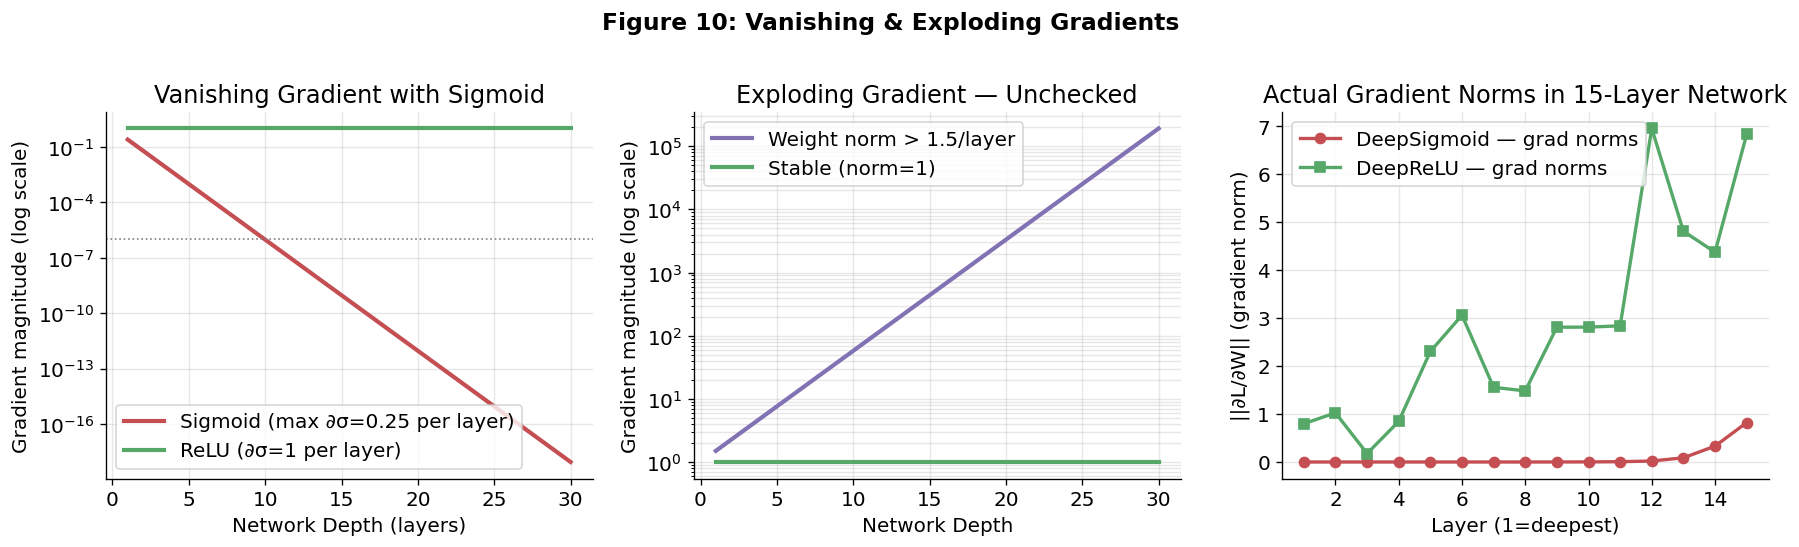

In [13]:
# Figure 10: Vanishing & Exploding Gradients — simulation across depth
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

depths = np.arange(1, 31)

# ── Sigmoid: max derivative 0.25 ──
sig_grad = 0.25**depths        # worst case: all layers at saturated sigmoid
relu_grad = np.ones(len(depths)) * 1.0  # ReLU: gradient = 1 (when not dead)

# ── Plot 1: Gradient magnitude vs depth ──
axes[0].semilogy(depths, sig_grad, lw=2.5, color='#C44E52',
                 label='Sigmoid (max ∂σ=0.25 per layer)')
axes[0].semilogy(depths, relu_grad, lw=2.5, color='#55A868',
                 label='ReLU (∂σ=1 per layer)')
axes[0].set_xlabel('Network Depth (layers)'); axes[0].set_ylabel('Gradient magnitude (log scale)')
axes[0].set_title('Vanishing Gradient with Sigmoid')
axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)
axes[0].axhline(1e-6, color='grey', ls=':', lw=1, label='Effectively zero')

# ── Plot 2: Exploding gradient ──
exploding = 1.5**depths
axes[1].semilogy(depths, exploding, lw=2.5, color='#8172B3',
                 label='Weight norm > 1.5/layer')
axes[1].semilogy(depths, relu_grad, lw=2.5, color='#55A868', label='Stable (norm=1)')
axes[1].set_xlabel('Network Depth'); axes[1].set_ylabel('Gradient magnitude (log scale)')
axes[1].set_title('Exploding Gradient — Unchecked')
axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

# ── Plot 3: PyTorch simulation — gradient norms per layer ──
torch.manual_seed(7)

class DeepSigmoid(nn.Module):
    def __init__(self, n_layers):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(8,8) for _ in range(n_layers)])
    def forward(self, x):
        for layer in self.layers:
            x = torch.sigmoid(layer(x))
        return x.sum()

class DeepReLU(nn.Module):
    def __init__(self, n_layers):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(8,8) for _ in range(n_layers)])
    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        return x.sum()

n_layers = 15
x_in = torch.randn(1, 8)

norms_sigmoid, norms_relu = [], []
for ModelClass, norms in [(DeepSigmoid, norms_sigmoid), (DeepReLU, norms_relu)]:
    m = ModelClass(n_layers)
    # Init weights with slightly larger values to see exploding/vanishing
    for p in m.parameters():
        nn.init.normal_(p, std=0.5)
    out = m(x_in)
    out.backward()
    for i, layer in enumerate(m.layers):
        norms.append(layer.weight.grad.norm().item())

axes[2].plot(range(1, n_layers+1), norms_sigmoid, 'o-', lw=2,
             color='#C44E52', label='DeepSigmoid — grad norms')
axes[2].plot(range(1, n_layers+1), norms_relu,    's-', lw=2,
             color='#55A868', label='DeepReLU — grad norms')
axes[2].set_xlabel('Layer (1=deepest)'); axes[2].set_ylabel('||∂L/∂W|| (gradient norm)')
axes[2].set_title('Actual Gradient Norms in 15-Layer Network')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Figure 10: Vanishing & Exploding Gradients', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Gradient Clipping

#### Intuition
Gradient clipping is the **seat belt** against exploding gradients.
When a gradient grows catastrophically large, we "clip" its magnitude to a safe maximum — keeping direction but constraining step size.

Two strategies:

**1. Clip by value** — clip each gradient component individually:
$$g_i \leftarrow \text{clip}(g_i,\, -c,\, c)$$
Problem: distorts gradient direction (each dimension clipped independently).

**2. Clip by norm** — scale the entire gradient vector to have max norm $c$:
$$\vec{g} \leftarrow \frac{c}{\max(c,\; \|\vec{g}\|_2)} \cdot \vec{g}$$
Preferred: **preserves gradient direction**, only shrinks magnitude.

#### When to use
- **RNN training** (BPTT with long sequences)
- Any time you see `loss = NaN` or weights blowing up
- Transformer training (used by default in HuggingFace)

#### PyTorch API
```python
# After loss.backward(), before optimizer.step()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

#### Choosing `max_norm`
- Start with `max_norm=1.0` — works for most cases
- Monitor gradient norms during training; set threshold above typical but below explosive

#### Interview Questions: Gradient Clipping
> **Q: Clip by value vs clip by norm — which is better?**
> A: Clip by norm. It scales the entire gradient vector uniformly, preserving the direction of the gradient. Clip by value distorts the direction (each component clipped independently).

> **Q: When would you add gradient clipping even without exploding gradients?**
> A: During early training with aggressive learning rates, or when training on noisy data where occasional very large gradients can destabilise training momentarily.

> **Q: Does gradient clipping change the optimal solution?**
> A: No — it's a constraint on step size, not a change to the loss landscape. It slows progress when gradients are large but doesn't alter the minimum.


Before clipping:
  weight: grad norm = 196.4012
  bias: grad norm = 3.7032

After clip_grad_norm_(max_norm=1.0):
  weight: grad norm = 0.9998
  bias: grad norm = 0.0189

Total grad norm before clipping: 196.4362
After clipping all norms are within max_norm=1.0 ✓


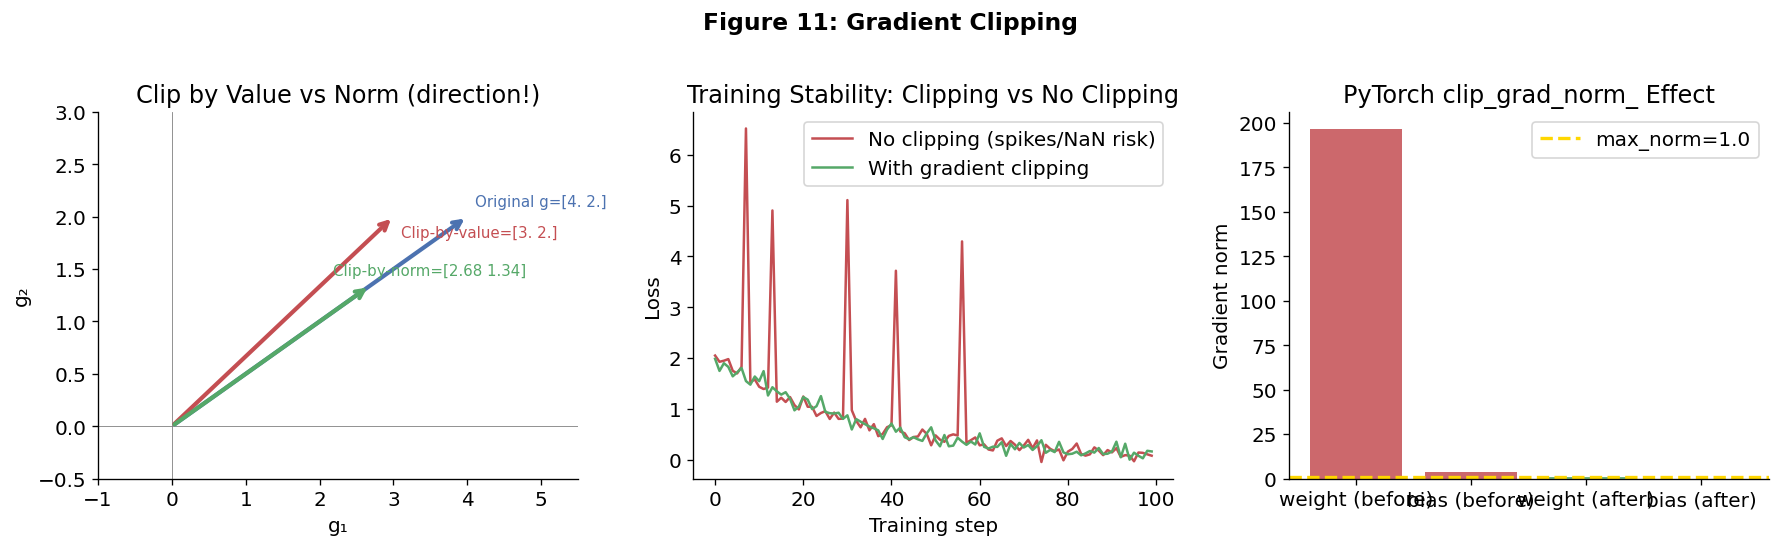

In [14]:
# Figure 11: Gradient Clipping — value vs norm, effect on direction
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Clip by value vs norm in 2D ──
g = np.array([4.0, 2.0])   # original gradient vector
c = 3.0                     # clip threshold

# Clip by value
g_clip_val  = np.clip(g, -c, c)

# Clip by norm
g_norm = np.linalg.norm(g)
g_clip_norm = g * (c / max(c, g_norm))

ax = axes[0]
ax.set_xlim(-1, 5.5); ax.set_ylim(-0.5, 3)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.annotate("", xy=(g[0], g[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color='#4C72B0', lw=2.5))
ax.text(g[0]+0.1, g[1]+0.1, f'Original g={g}', color='#4C72B0', fontsize=9)
ax.annotate("", xy=(g_clip_val[0], g_clip_val[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color='#C44E52', lw=2.5))
ax.text(g_clip_val[0]+0.1, g_clip_val[1]-0.2, f'Clip-by-value={g_clip_val}', color='#C44E52', fontsize=9)
ax.annotate("", xy=(g_clip_norm[0], g_clip_norm[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color='#55A868', lw=2.5))
ax.text(g_clip_norm[0]-0.5, g_clip_norm[1]+0.1, f'Clip-by-norm={g_clip_norm.round(2)}', color='#55A868', fontsize=9)
ax.set_title('Clip by Value vs Norm (direction!)'); ax.set_xlabel('g₁'); ax.set_ylabel('g₂')

# ── Plot 2: Training loss with vs without clipping (simulated) ──
np.random.seed(42)
steps = np.arange(100)
# Simulate loss with occasional spikes
loss_no_clip = 2.0 * np.exp(-steps*0.03) + 0.1*np.random.randn(100)
spikes = np.random.choice(100, 5, replace=False)
loss_no_clip[spikes] += np.random.uniform(2, 5, 5)   # large spikes

loss_clip = 2.0 * np.exp(-steps*0.03) + 0.1*np.random.randn(100)
loss_clip = np.clip(loss_clip, 0, 3)                  # clipped training

axes[1].plot(steps, loss_no_clip, color='#C44E52', lw=1.5, label='No clipping (spikes/NaN risk)')
axes[1].plot(steps, loss_clip,    color='#55A868', lw=1.5, label='With gradient clipping')
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training Stability: Clipping vs No Clipping'); axes[1].legend()

# ── Plot 3: PyTorch gradient clipping demo ──
torch.manual_seed(0)
model = nn.Linear(10, 1)

# Simulate a large gradient
x_in = torch.randn(1, 10) * 15.0   # large input → large gradient
y_in = torch.zeros(1, 1)
loss = nn.MSELoss()(model(x_in), y_in)
loss.backward()

grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
print("Before clipping:")
for p_name, p in model.named_parameters():
    if p.grad is not None:
        print(f"  {p_name}: grad norm = {p.grad.norm().item():.4f}")

total_norm_before = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

print(f"\nAfter clip_grad_norm_(max_norm=1.0):")
for p_name, p in model.named_parameters():
    if p.grad is not None:
        print(f"  {p_name}: grad norm = {p.grad.norm().item():.4f}")
print(f"\nTotal grad norm before clipping: {total_norm_before:.4f}")
print(f"After clipping all norms are within max_norm=1.0 ✓")

axes[2].bar(['weight (before)','bias (before)','weight (after)','bias (after)'],
            grad_norms + [p.grad.norm().item() for p in model.parameters() if p.grad is not None],
            color=['#C44E52','#C44E52','#55A868','#55A868'], alpha=0.85)
axes[2].axhline(1.0, color='gold', ls='--', lw=2, label='max_norm=1.0')
axes[2].set_ylabel('Gradient norm'); axes[2].set_title('PyTorch clip_grad_norm_ Effect')
axes[2].legend()

plt.suptitle('Figure 11: Gradient Clipping', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---

## 4. NumPy: Full Forward + Backward Pass from Scratch

Building a complete training loop using only NumPy — no autograd, no frameworks.
This forces us to manually implement every gradient equation we derived above.

### Architecture
- Input: 2 features
- Hidden: 4 neurons, ReLU
- Output: 1 neuron, sigmoid (binary classification)
- Loss: Binary Cross-Entropy


Final loss: 0.6536
Final accuracy: 75.5%


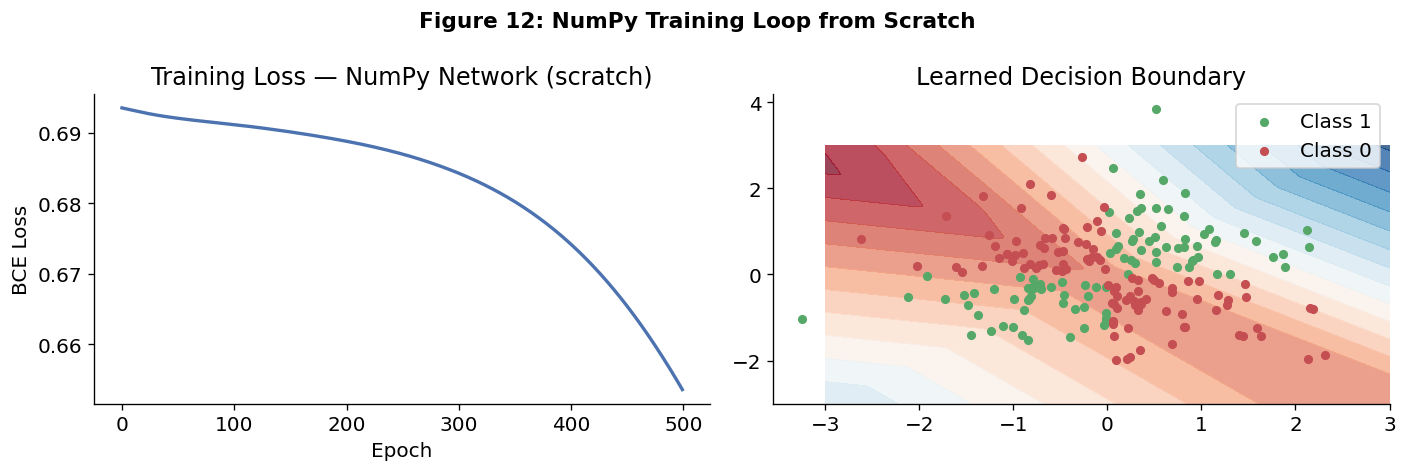

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Dataset: XOR-like problem ──────────────────────────────
N = 200
X = np.random.randn(N, 2)
Y = ((X[:,0] * X[:,1]) > 0).astype(float).reshape(-1, 1)

def sigmoid(z):     return 1 / (1 + np.exp(-z))
def sigmoid_d(z):   return sigmoid(z) * (1 - sigmoid(z))
def relu(z):        return np.maximum(0, z)
def relu_d(z):      return (z > 0).astype(float)
def bce(yhat, y):   return -np.mean(y*np.log(yhat+1e-9) + (1-y)*np.log(1-yhat+1e-9))

# ── Weight initialisation ────────────────────────────────
n_in, n_h, n_out = 2, 4, 1
W1 = np.random.randn(n_h, n_in)  * 0.1
b1 = np.zeros((n_h, 1))
W2 = np.random.randn(n_out, n_h) * 0.1
b2 = np.zeros((n_out, 1))
lr = 0.05

loss_history = []

# ── Training loop ────────────────────────────────────────
for epoch in range(500):
    # ─ Forward pass ─
    Z1 = W1 @ X.T + b1               # (4, N)
    A1 = relu(Z1)                    # (4, N)
    Z2 = W2 @ A1 + b2                # (1, N)
    A2 = sigmoid(Z2)                 # (1, N)  = ŷ

    loss = bce(A2, Y.T)
    loss_history.append(loss)

    # ─ Backward pass ─
    dL_dA2 = -(Y.T / (A2+1e-9) - (1-Y.T)/(1-A2+1e-9)) / N  # (1, N)
    dL_dZ2 = dL_dA2 * sigmoid_d(Z2)                           # (1, N)
    dL_dW2 = dL_dZ2 @ A1.T                                    # (1, 4)
    dL_db2 = dL_dZ2.sum(axis=1, keepdims=True)                # (1, 1)

    dL_dA1 = W2.T @ dL_dZ2                                    # (4, N)
    dL_dZ1 = dL_dA1 * relu_d(Z1)                              # (4, N)
    dL_dW1 = dL_dZ1 @ X                                       # (4, 2)
    dL_db1 = dL_dZ1.sum(axis=1, keepdims=True)                # (4, 1)

    # ─ Optimizer step (SGD) ─
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

# ── Results ──────────────────────────────────────────────
predictions = (A2 > 0.5).flatten()
accuracy    = np.mean(predictions == Y.flatten())
print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Final accuracy: {accuracy*100:.1f}%")

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color='#4C72B0', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss — NumPy Network (scratch)')

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-3,3,100), np.linspace(-3,3,100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z1g = W1 @ grid.T + b1
A1g = relu(Z1g)
Z2g = W2 @ A1g + b2
probs = sigmoid(Z2g).reshape(xx.shape)
axes[1].contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.75)
axes[1].scatter(X[Y.flatten()==1,0], X[Y.flatten()==1,1], c='#55A868', s=20, label='Class 1')
axes[1].scatter(X[Y.flatten()==0,0], X[Y.flatten()==0,1], c='#C44E52', s=20, label='Class 0')
axes[1].set_title('Learned Decision Boundary'); axes[1].legend()

plt.suptitle('Figure 12: NumPy Training Loop from Scratch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 5. PyTorch: The Same Network with `nn.Module` + `autograd`

Same XOR-like task, same architecture — but now using PyTorch's autograd.
Notice how much shorter the code is, while doing **exactly the same math**.


Final loss: 0.5482
Accuracy:   71.0%


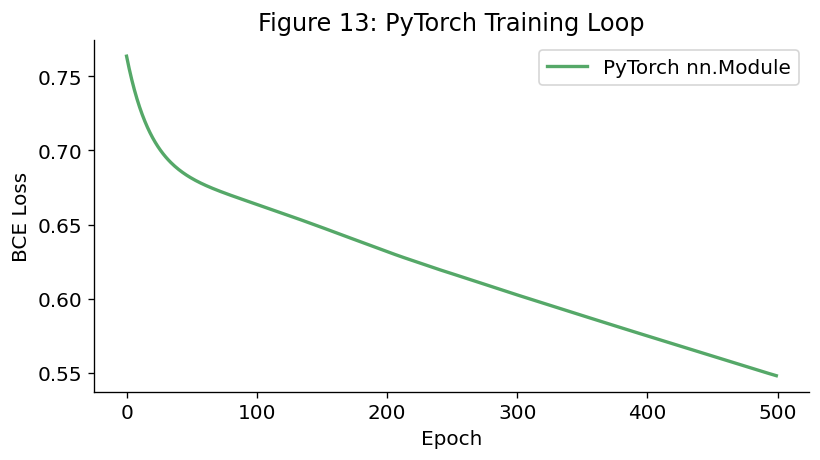


5-step training loop (always in this order):
  1. optimizer.zero_grad()  — clear accumulated gradients
  2. y_hat = model(x)       — forward pass
  3. loss = criterion(...)  — compute scalar loss
  4. loss.backward()        — backprop (chain rule)
  5. optimizer.step()       — update weights


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# ── Dataset ────────────────────────────────────────────────
N = 200
X_np = np.random.randn(N, 2).astype(np.float32)
Y_np = ((X_np[:,0] * X_np[:,1]) > 0).astype(np.float32).reshape(-1, 1)

X_t = torch.from_numpy(X_np)
Y_t = torch.from_numpy(Y_np)

# ── Model ──────────────────────────────────────────────────
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# ── Training loop ──────────────────────────────────────────
losses = []
for epoch in range(500):
    optimizer.zero_grad()          # ① clear old gradients
    y_hat = model(X_t)             # ② forward pass
    loss  = criterion(y_hat, Y_t)  # ③ compute loss
    loss.backward()                # ④ backpropagation
    optimizer.step()               # ⑤ update weights
    losses.append(loss.item())

with torch.no_grad():
    preds = (model(X_t) > 0.5).numpy().flatten()
print(f"Final loss: {losses[-1]:.4f}")
print(f"Accuracy:   {np.mean(preds == Y_np.flatten())*100:.1f}%")

# ── Plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color='#55A868', lw=2, label='PyTorch nn.Module')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Figure 13: PyTorch Training Loop')
ax.legend()
plt.tight_layout()
plt.show()

print("\n5-step training loop (always in this order):")
print("  1. optimizer.zero_grad()  — clear accumulated gradients")
print("  2. y_hat = model(x)       — forward pass")
print("  3. loss = criterion(...)  — compute scalar loss")
print("  4. loss.backward()        — backprop (chain rule)")
print("  5. optimizer.step()       — update weights")


---

## 6. Master Interview Q&A Cheatsheet

### Level 1 — Beginner (Entry Level / Internship)

> **Q: What are the 4 steps of neural network training?**
> A: (1) Forward pass — compute predictions, (2) Loss computation — measure error, (3) Backpropagation — compute gradients, (4) Optimizer step — update weights.

> **Q: What is a loss function and why do we need it?**
> A: A loss function converts the difference between prediction and ground truth into a single scalar. It's the signal the optimizer uses to improve the model. Without it, we can't quantify "how wrong" the model is.

> **Q: When would you use MSE vs Cross-Entropy?**
> A: MSE for regression (continuous outputs). Cross-Entropy for classification (discrete outputs / probabilities). MSE applied to classification has poor gradient behaviour through sigmoid/softmax.

> **Q: What does `.backward()` do in PyTorch?**
> A: It computes gradients of the loss with respect to all parameters using reverse-mode automatic differentiation (backpropagation through the computational graph).

> **Q: Why do we call `optimizer.zero_grad()` before backward?**
> A: PyTorch accumulates gradients by default. If not zeroed, gradients from previous batches are added to current gradients, causing incorrect parameter updates.

---

### Level 2 — Mid-Level (1–3 years experience)

> **Q: Derive the gradient of BCE + Sigmoid output.**
> A: Let $z$ be the logit, $\hat{y} = \sigma(z)$, loss $= -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$.
> $\frac{\partial L}{\partial z} = \hat{y} - y$. Clean and simple — demonstrates why sigmoid+BCE is paired.

> **Q: What is vanishing gradient and how does it affect training?**
> A: When gradients are multiplied through many layers, if each factor is < 1 (e.g., sigmoid derivative ≤ 0.25), the product → 0 exponentially. Early layers stop learning. Fixed by ReLU, BatchNorm, residual connections.

> **Q: Why is MAE non-differentiable and how do we handle it?**
> A: At the exact prediction point (error=0), |error| has a kink. We use a subgradient = 0 at that point. In practice this causes no problems, but the constant gradient (±1) outside causes oscillation near the minimum.

> **Q: What is the difference between BCELoss and BCEWithLogitsLoss in PyTorch?**
> A: `BCEWithLogitsLoss` combines sigmoid + BCE in a numerically stable single operation using the log-sum-exp trick. `BCELoss` expects probabilities as input and is numerically unstable for extreme logits. Always use `BCEWithLogitsLoss`.

> **Q: Why does Huber loss work well for object detection?**
> A: Object detection bounding box regression has occasional large errors (poorly matched anchors). Huber is quadratic (smooth gradient) for small errors, linear (robust to outliers) for large errors — ideal for this use case.

> **Q: Explain reverse-mode vs forward-mode autodiff.**
> A: Forward mode: computes gradient of all outputs w.r.t. one input (one pass per input). Reverse mode: computes gradients of one scalar output (loss) w.r.t. all inputs (one backward pass). For networks with one loss and millions of params, reverse mode reduces cost from O(params) passes to O(1) backward.

---

### Level 3 — Senior MLE / Staff Engineer

> **Q: A model's loss becomes NaN after a few thousand steps. Walk me through your debugging process.**
> A: (1) Check gradient norms per layer — are any layers exploding? (2) Add `clip_grad_norm_` as immediate mitigation. (3) Check data for NaN/inf inputs. (4) Check learning rate — might be too large. (5) Check loss function: log(0) in BCE/CCE? Add epsilon. (6) Check for in-place operations on `requires_grad` tensors. (7) Inspect loss landscape — sharp minimum? Try weight decay or init from a different seed.

> **Q: When would you choose Huber over MSE in a production system?**
> A: When the data has long-tailed noise (sensor errors, annotation mistakes, or adversarial examples). Huber's bounded gradient prevents these outliers from dominating the weight update. In practice: start with MSE, switch if gradient norms show spikes correlating with outlier batches.

> **Q: How does label smoothing prevent overfitting and improve calibration?**
> A: Hard labels push the model toward infinite logits (perfectly confident). Label smoothing caps the "target confidence" at $1-\epsilon$, preventing logit saturation. This improves NLL generalisation, Temperature Scaling calibration, and has been shown to improve accuracy on ImageNet (+0.4% top-1 in original paper).

> **Q: Why do flat minima generalise better than sharp minima?**
> A: A sharp minimum has high curvature — small shifts in weights (e.g., due to domain shift) cause large loss jumps. A flat minimum is robust to perturbations. SAM (Sharpness-Aware Minimisation) explicitly seeks flat minima by perturbing weights before computing gradients.

> **Q: How would you debug vanishing gradients in a production model?**
> A: (1) Log per-layer gradient norms each step — a norm < 1e-6 indicates vanishing. (2) Profile which activation function is used — sigmoid/tanh more susceptible. (3) Check initialisation — poor init accelerates vanishing. (4) Add BatchNorm layers. (5) Consider residual connections. (6) Use gradient checkpointing to trade memory for gradient flow analysis at scale.
